0. <a id="input_0"></a><span style="background-color:#FEDA8B;">
Remember to add your declaration of collaborations, external resources and AI use.
</span>

# Basics of frequent itemset mining on the *Congressional Voting Records* dataset

## Preamble

### Importing libraries

First, we import the libraries that we will need to load, process and visualize the data.

Details about the different libraries and provided functions can be found in their respective documentation:
- `numpy` for numerical calculations https://numpy.org/doc/stable/
- `pandas` for data manipulation and analysis https://pandas.pydata.org/docs/
- `pyplot` from `matplotlib` for basic plotting functionalities https://matplotlib.org/stable/
- `seaborn` for data visualization https://seaborn.pydata.org/

The first three lines below are Python 'magic commands', respectively to display plots inline in the notebook, to install the `seaborn` library and to display plots as scalable vector graphics (svg). Depending on goals and on the configuration of the IPython kernel used, different magic commands might need to be (un)commented.
The last three lines are to customize the style of figures, especially adding a light gray grid and increasing the default figure width.

In [1]:
# # %matplotlib inline
# %pip install seaborn
# %config InlineBackend.figure_formats = ["svg"]

import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn

seaborn.set_theme(style="white",
                  rc={"axes.grid": True, "grid.color": "#eaeaf2", "xtick.bottom": True, "ytick.left": True,
                     "figure.figsize": (10, 5)})

In addition, we will use the Python implementation of a simplified version of the *Eclat/LCM* frequent itemset mining algorithm by C. Borgelt (https://borgelt.net/eclat.html).
Besides, we import the `itertools` module for generating combinations of items.

In [2]:
from pyfim import fim
import itertools

### Repeatability

We initialize a `numpy.random.Generator` instance with a fixed seed and store it as variable `RNG`, to be used whenever we need a *numpy* random sampling function.
This makes the analysis in this notebook repeatable. That is, it ensures that every time we restart the kernel and run all cells from top to bottom we obtain the same results, so that we can meaningfully discuss them.
(setup a *numpy* pseudo-random number generator)
If we run cells repeatedly or in a different order, since the sequence of calls to the random number generator will be different, we might obtain different results.
In order to explore the behavior of the methods, for example during development, we initialize the generator without a seed, so that a fresh unpredictable value will be used.

For details about controlling randomness when using *numpy*, see https://numpy.org/doc/stable/reference/random/index.html.

1. <a id="input_1"></a><span style="background-color:#FEDA8B;">
Set the value of `SEED` in the first line below to your student number.
</span>

In [3]:
# ✏️
SEED = 1
RNG = numpy.random.default_rng(SEED)
# RNG = numpy.random.default_rng()

### Data source

Quoting the dataset information from the [*UCI* webpage](https://archive.ics.uci.edu/dataset/105/congressional+voting+records)

> This data set includes votes for each of the U.S. House of Representatives Congressmen on the 16 key votes identified by the CQA.
> The CQA lists nine different types of votes: voted for, paired for, and announced for (these three simplified to yea), voted against, paired against, and announced against (these three simplified to nay), voted present, voted present to avoid conflict of interest, and did not vote or otherwise make a position known (these three simplified to an unknown disposition).

The [*Congressional Quarterly Almanac (CQA)*](https://library.cqpress.com/cqalmanac/) is a reference source about the activities of each annual session of the United States Congress from 1945 to 2020.

### Loading the data

We load the data from the `house-votes-84.data` file. This file does not contain names for the columns, they can be found in the `house-votes-84.names` file.

We write the list of (shortened) column names and provide it as the `names` input parameter to the `read_csv` function.

In [4]:
# cnames = ["party", "handicapped-infants", "water-project-cost-sharing", "adoption-of-the-budget-resolution",
#          "physician-fee-freeze", "el-salvador-aid", "religious-groups-in-schools", "anti-satellite-test-ban",
#          "aid-to-nicaraguan-contras", "mx-missile", "immigration", "synfuels-corporation-cutback",
#          "education-spending", "superfund-right-to-sue", "crime", "duty-free-exports",
#          "export-administration-act-south-africa"]
cnames = ["party", "infants", "water", "budget", "physician", "el-salvador", "religious", "satellite",
          "nicaragua", "missile", "immigration", "synfuels",
          "education", "superfund", "crime", "exports", "south-africa"]
congress_path = "./house-votes-84.data"
congress_dtf = pandas.read_csv(congress_path, sep=",", names=cnames)

We show an outline of the loaded dataset...

In [5]:
congress_dtf

,party,infants,water,budget,physician,el-salvador,religious,satellite,nicaragua,missile,immigration,synfuels,education,superfund,crime,exports,south-africa
0,republican,n,y,n,y,y,y,n,n,n,y,?,y,y,y,n,y
1,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
2,democrat,?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n
3,democrat,n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y
4,democrat,y,y,y,n,y,y,n,n,n,n,y,?,y,y,y,y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,republican,n,n,y,y,y,y,n,n,y,y,n,y,y,y,n,y
431,democrat,n,n,y,n,n,n,y,y,y,y,n,n,n,n,n,y
432,republican,n,?,n,y,y,y,n,n,n,n,y,y,y,y,n,y
433,republican,n,n,n,y,y,y,?,?,?,?,n,y,y,y,n,y


...and some descriptive statistics.

Since all columns are categorical, the statistics include for each column
- `count` the total number of values, i.e. the number of rows minus the number of missing values,
- `unique` the number of distinct values,
- `top` the most frequent value, and
- `freq` the occurrence count of the most frequent value.

In [6]:
congress_dtf.describe()

,party,infants,water,budget,physician,el-salvador,religious,satellite,nicaragua,missile,immigration,synfuels,education,superfund,crime,exports,south-africa
count,435,435,435,435,435,435,435,435,435,435,435,435,435,435,435,435,435
unique,2,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
top,democrat,n,y,y,n,y,y,y,y,y,y,n,n,y,y,n,y
freq,267,236,195,253,247,212,272,239,242,207,216,264,233,209,248,233,269


Each of the 435 rows in the dataset represents an elected member of the United States House of Representatives.

The first column indicates the party affiliation of the corresponding representative, as either democrat or republican.
Each of the remaining sixteen columns corresponds to a key vote taken during the second session of the 98th United States Congress, i.e. between January 23 and October 12, 1984.

In this dataset, the vote types are simplified to three outcomes
- **y**, for *Yea*, i.e. vote in favor,
- **n**, for *Nay*, i.e. vote against,
- **?**, no vote, in particular abstention.

Here, we will refer the sixteen votes as *roll calls* and identify each one using the associated short column name.
We will refer to a vote cast either in favor or against as an *expressed vote* and to the third outcome as *abstention*.

In [7]:
parties = sorted(congress_dtf["party"].unique())
print("The dataset contains the votes of " +
      " and ".join(["%s %ss" % (c, p) for (p, c) in congress_dtf["party"].value_counts().items()])+".")

The dataset contains the votes of 267 democrats and 168 republicans.


### Visualizing votes per party

Throughout, we will use colors to represent the different combinations of party and vote type.

Following common conventions, we will use shades of blue for the Democratic Party and shades of red for the Republican Party.
We will use different shades of blue and red to represent the different vote types.
To do this, we will use the 'coolwarm' color map, which varies from bright blue to bright red, through grayish shades.

We map combinations of party and vote type to values in the unit range, so that pairs involving the Democratic Party map to values in the first half while pairs involving the Republican Party map to the second half, and so that values assigned to the same vote type for the two parties are symmetric around the middle of the interval.

In [8]:
codes_votes = [(("democrat", "y"), 0.01), (("democrat", "n"), 0.2), (("democrat", "?"), 0.4), (("democrat", "-"), 0.49), # democrat
             (("republican", "-"), 0.51), (("republican", "?"), 0.6), (("republican", "n"), 0.8), (("republican", "y"), 0.99)]  # republican
map_votes = dict(codes_votes)

We write a function to get a contrasting shade for a given color. That is, for a given value in the unit interval, function `get_contrasting_color` returns the color from the palette that corresponds to a value at the opposite end of the same half, so that the corresponding colors are contrasting shades of the hue.

In [9]:
def get_contrasting_color(vfrac, palette):
    if vfrac < 0.15:
        return palette(0.55)
    elif vfrac < 0.45:
        return palette(0.99)
    elif vfrac < 0.55:
        # in the mid-range, return black
        return (0.,0.,0.,1.)
    elif vfrac < 0.85:
        return palette(0.01)
    else:
        return palette(0.45)

We write a function for plotting the counts of vote types as a stacked horizontal histogram bar.
For readability, we assign somewhat longer labels to the three vote types (see `vote_lbls`).

In [10]:
def make_bar_stack(ax, series, codes_votes, plot_parameters={}, bottom=0, height=1, yoffset_party_lbls=0.1, set_lims=False):
    """Make a stacked horizontal histogram bar for the votes in the series, mapped the provided numerical codes.

        Parameters
        ----------
        ax: pyplot.Axes
            The axes in which to plot the data
        series: pandas.Series
            The series containing the values to plot
        codes_votes: list of tuples
            The sorted list of (party, vote type) pairs with their associated numerical value, as used to obtain the series
        plot_parameters: dict
            Parameters for plotting, such as
            "party_lbls" and "vote_lbls", labels for the parties and vote types, respectively
            "fontsize", "alpha"
        bottom: float
            The y-coordinate of the bottom of the bar
        height: float
            The height of the bar
        yoffset_party_lbls: float
            Offset along the y-coordinate between the bar and the party labels, if None no party label is generated
        set_lims: bool
            Whether to reset the axes limits to wrap around the bar and to turn off the axes
    """

    party_lbls = plot_parameters.get("party_lbls", {"democrat": "Democrats", "republican": "Republicans"})
    vote_lbls = plot_parameters.get("vote_lbls", {"y": "Yea", "n": "Nay", "?": "Abs", "-": ""})
    palette = plot_parameters.get("palette", seaborn.color_palette("coolwarm", as_cmap=True))

    vc = dict(series.value_counts().items())
    sorted_ks, sorted_vs = zip(*codes_votes)
    sorted_colors = [palette(v) for v in sorted_vs]
    sorted_tcolors = [get_contrasting_color(1-v, palette) for v in sorted_vs]
    sorted_counts = [vc.get(v, 0) for v in sorted_vs]
    sorted_cumsum = numpy.cumsum([0]+sorted_counts)

    ax.bar(x=sorted_cumsum[:-1], width=sorted_counts, bottom=bottom, height=height, align="edge", color=sorted_colors)
    for j in range(3):
        for i in [j, len(sorted_ks)-j-1]:
            ax.annotate(text="%s:%d" % (vote_lbls[sorted_ks[i][1]], sorted_counts[i]),
                    xy=((sorted_cumsum[i]+sorted_cumsum[i+1])/2, bottom+0.1+((i-2*(i!=j))%3)*0.3*height),
                    ha="center", fontsize=plot_parameters.get("fontsize", "small"), color=sorted_tcolors[i],
                    bbox=dict(boxstyle="round", pad=.1, lw=0, fc=sorted_colors[i], alpha=plot_parameters.get("alpha", 0.8)))

    if yoffset_party_lbls is not None:
        for (end_id, from_id, to_id) in [(0, 0, 3), (-1, -4, -1)]:
            ax.plot([sorted_cumsum[from_id]+.8, sorted_cumsum[to_id]-.8],
                    [bottom+height+yoffset_party_lbls/2, bottom+height+yoffset_party_lbls/2],
                    color=sorted_colors[end_id], linewidth=1)
            ax.annotate(text=party_lbls[sorted_ks[end_id][0]],
                    xy=((sorted_cumsum[from_id]+sorted_cumsum[to_id])/2, bottom+height+yoffset_party_lbls),
                    ha="center", fontsize=plot_parameters.get("fontsize", "small"), color=sorted_colors[end_id])

    if set_lims:
        ax.set_xlim([0, sorted_cumsum[-1]])
        ax.set_ylim([bottom, bottom+height+3*yoffset_party_lbls])
        ax.axis("off");

We visualize the distribution of vote types in the two parties for the sixteen roll calls in the dataset.

<a id="viz_party-votes"></a>That is, for each roll call in turn, we map the votes to numerical values and use the function to draw the corresponding histogram bar.

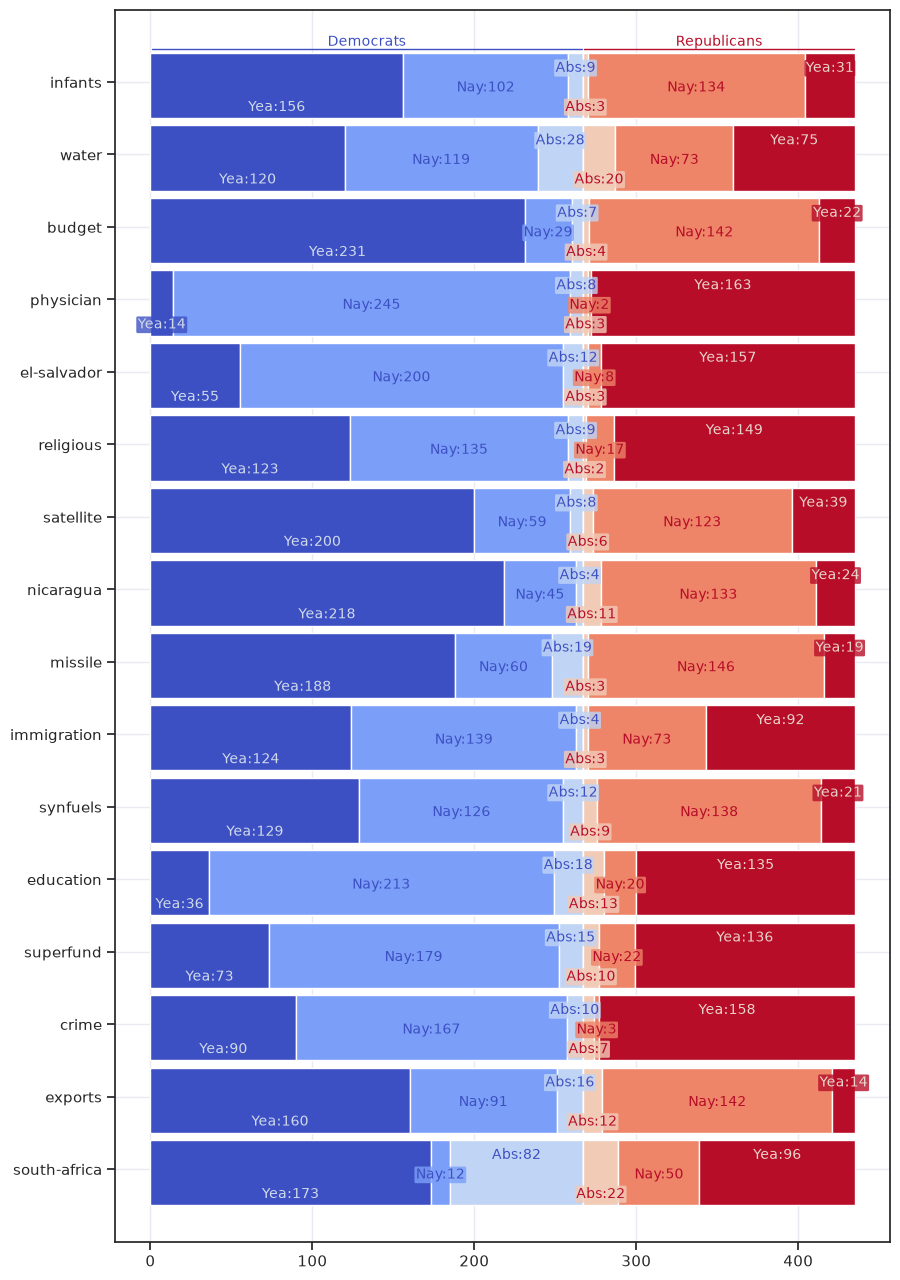

In [11]:
plot_parameters = {"fontsize": "small"}

fig = plt.figure(figsize=(10, 16))
ax = fig.add_subplot()

for i, rc in enumerate(cnames[1:]):
    series = pandas.Series([map_votes.get(tuple(v)) for v in congress_dtf[["party", rc]].values])

    make_bar_stack(ax, series, codes_votes, plot_parameters, bottom=-i, height=0.9,
                                     yoffset_party_lbls=0.1 if i == 0 else None)

ax.set_yticks(*zip(*[(-i+.5, rc) for i, rc in enumerate(cnames[1:])]));
ax.set_ylim([-len(cnames[1:])+.5, 1.5]);

Obviously, in this dataset the number of representatives affiliated with either party is the same for all roll calls, but we can see substantial variations in the distribution of votes.

Some votes seem fairly consensual within a party, with all but five republican representatives voting 'Yea' on 'physician', for example. The votes are much more split on some roll calls for both parties, like 'immigration' and even more so 'water'.

The *UCI* dataset provides only very limited information about what the roll calls are about, with mere keywords used as column headers.
The dataset only records the party affiliation of each representative, but no information about their personal identity or even the corresponding congressional district.

### Complementary data

In order to better understand the data and be able to analyze it more deeply, [in a separate notebook](https://github.com/nurblageij/data-exploration/blob/main/datasets/explore_congress.ipynb) we matched the records to another source that keeps track of votes taken at the United States Congress and provides more detailed information, namely the [*Voteview* website](https://voteview.com/).

We load the information about the sixteen roll calls.

In [12]:
summary_rcs_dtf = pandas.read_csv("voteview_rollcalls.csv", index_col="shortname")
summary_rcs_dtf

,rollnumber,date,bill_number,dtl_desc,vv_link
shortname,,,,,
infants,511,1984-02-02,HR1904,TO AMEND H.R. 1904 WITH AN AMENDMENT IN THE NA...,https://voteview.com/rollcall/RH0980511
water,540,1984-03-20,HR1652,TO AMEND THE SOLOMON AMENDMENT TO H.R. 1652 WI...,https://voteview.com/rollcall/RH0980540
budget,563,1984-04-05,HCON280,TO AGREE TO H. CON. RES. 280. (MOTION PASSED),https://voteview.com/rollcall/RH0980563
physician,572,1984-04-12,HR5394,TO RECOMMIT H.R. 5394 TO THE COMMITTEE ON WAYS...,https://voteview.com/rollcall/RH0980572
el-salvador,623,1984-05-10,HR5119,TO AMEND H.R. 5119 TO INCREASE THE AUTHORIZATI...,https://voteview.com/rollcall/RH0980623
religious,627,1984-05-15,HR5345,"TO SUSPEND THE RULES AND PASS H.R. 5345, A BIL...",https://voteview.com/rollcall/RH0980627
satellite,650,1984-05-23,HR5167,TO AMEND THE BROWN AMENDMENT TO H.R. 5167. TH...,https://voteview.com/rollcall/RH0980650
nicaragua,660,1984-05-24,HJR492,TO RECEDE FROM DISAGREEMENT TO A SENATE AMENDM...,https://voteview.com/rollcall/RH0980660
missile,676,1984-05-31,HR5167,TO AMEND THE DICKINSON AMENDMENT TO H.R. 5167....,https://voteview.com/rollcall/RH0980676


We can find the roll number, date, bill number, description and link to the *Voteview* page associated to each roll call. The index corresponds to the keywords used to identify each roll call in `congress_dtf`.

Next, we load the information about the members' votes.

In [13]:
H84mv_dtf = pandas.read_csv("voteview_members_votes.csv")
H84mv_dtf

,icpsr,bioname,born,died,occupancy,last_means,party_code,district_code,state_abbrev,state_icpsr,...,650,660,676,724,783,788,822,868,886,904
0,10721,"EDWARDS, William Jackson (Jack)",1928.0,2019.0,0,1,200,1,AL,41,...,6.0,6.0,6.0,1.0,9.0,1.0,1.0,1.0,6.0,1.0
1,10717,"DICKINSON, William Louis",1925.0,2008.0,0,1,200,2,AL,41,...,6.0,6.0,6.0,6.0,6.0,1.0,1.0,1.0,6.0,9.0
2,11037,"NICHOLS, William Flynt",1918.0,1988.0,0,1,100,3,AL,41,...,6.0,6.0,6.0,6.0,1.0,6.0,1.0,1.0,6.0,6.0
3,11000,"BEVILL, Tom",1921.0,2005.0,0,1,100,4,AL,41,...,6.0,6.0,6.0,6.0,1.0,6.0,1.0,6.0,6.0,1.0
4,14419,"FLIPPO, Ronnie Gene",1937.0,NaN,0,1,100,5,AL,41,...,6.0,6.0,6.0,6.0,1.0,9.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,14675,"PETRI, Thomas Evert",1940.0,NaN,0,1,200,6,WI,25,...,6.0,6.0,1.0,1.0,6.0,1.0,1.0,1.0,6.0,1.0
431,12036,"OBEY, David Ross",1938.0,NaN,0,1,100,7,WI,25,...,1.0,1.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,1.0
432,14655,"ROTH, Toby A.",1938.0,NaN,0,1,200,8,WI,25,...,6.0,6.0,6.0,6.0,1.0,1.0,1.0,1.0,6.0,1.0
433,14657,"SENSENBRENNER, Frank James, Jr.",1943.0,NaN,0,1,200,9,WI,25,...,9.0,9.0,9.0,9.0,6.0,1.0,1.0,1.0,6.0,1.0


We can see the name, date of birth and of death of the members of the House of Representatives. The party each representative is affiliated with is indicated as a code, where the Democratic Party is represented by the value 100 whereas the Republican Party is represented by the value 200.
For each representative, we can also see which district and state they represent, as well as the census division and census region the state belongs to, along with a custom numerical code for sorting.
Finally, sixteen columns named with the respective roll numbers indicate the vote cast by each representative on the different roll calls using numerical cast codes such that values 1, 2 and 3 simplify to *Yea* ('y'), values 4, 5 and 6 simplify to *Nay* ('n'), while values 7, 8 and 9 simplify to no vote (?).

The representatives are listed to match those appearing in the *UCI* dataset, in the in the same order. So we can concatenate the two tables horizontally into an extended dataset `congress_ext_dtf`.

In [14]:
congress_ext_dtf = pandas.concat([congress_dtf, H84mv_dtf], axis=1)
congress_ext_dtf

,party,infants,water,budget,physician,el-salvador,religious,satellite,nicaragua,missile,...,650,660,676,724,783,788,822,868,886,904
0,republican,n,y,n,y,y,y,n,n,n,...,6.0,6.0,6.0,1.0,9.0,1.0,1.0,1.0,6.0,1.0
1,republican,n,y,n,y,y,y,n,n,n,...,6.0,6.0,6.0,6.0,6.0,1.0,1.0,1.0,6.0,9.0
2,democrat,?,y,y,?,y,y,n,n,n,...,6.0,6.0,6.0,6.0,1.0,6.0,1.0,1.0,6.0,6.0
3,democrat,n,y,y,n,?,y,n,n,n,...,6.0,6.0,6.0,6.0,1.0,6.0,1.0,6.0,6.0,1.0
4,democrat,y,y,y,n,y,y,n,n,n,...,6.0,6.0,6.0,6.0,1.0,9.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,republican,n,n,y,y,y,y,n,n,y,...,6.0,6.0,1.0,1.0,6.0,1.0,1.0,1.0,6.0,1.0
431,democrat,n,n,y,n,n,n,y,y,y,...,1.0,1.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,1.0
432,republican,n,?,n,y,y,y,n,n,n,...,6.0,6.0,6.0,6.0,1.0,1.0,1.0,1.0,6.0,1.0
433,republican,n,n,n,y,y,y,?,?,?,...,9.0,9.0,9.0,9.0,6.0,1.0,1.0,1.0,6.0,1.0


We use the complementary data to plot the distribution of ages of representatives in 1984, the year of the considered congress session.

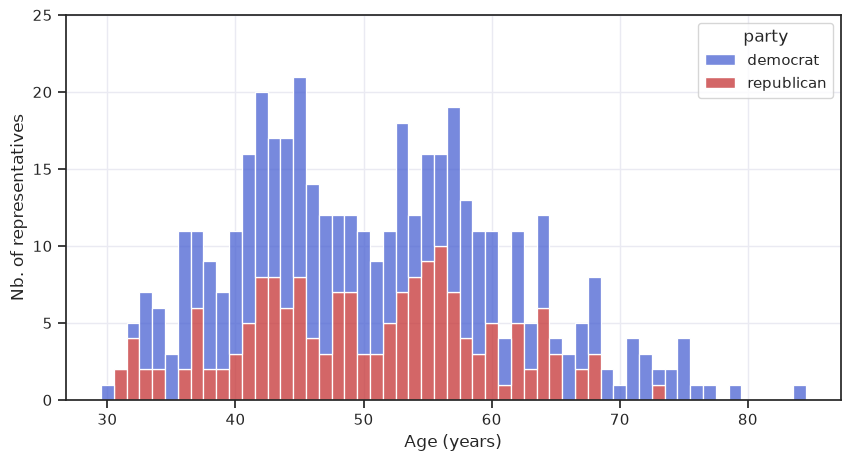

In [15]:
party_palette = seaborn.color_palette("coolwarm", as_cmap=True)
party_to_color = {"democrat": party_palette(0.05), "republican": party_palette(0.95)}

ax = seaborn.histplot(x=1984-congress_ext_dtf["born"], discrete=True, multiple="stack",
                      hue=congress_ext_dtf["party"], hue_order=["democrat", "republican"], palette=party_to_color);
ax.set_ylim([0,25]);
ax.set_xlabel("Age (years)");
ax.set_ylabel("Nb. of representatives");

The age of representatives ranges from 30 to 84 years old, with only one republican but more than a dozen democrats older than 70.

Each state belongs to one particular census division, which in turn belongs to one particular census region. We recover the mapping of states to divisions and regions, respectively, from the data.

In [16]:
reverse_map_divisions = dict(congress_ext_dtf[["state_abbrev", "division"]].values)
reverse_map_regions = dict(congress_ext_dtf[["state_abbrev", "region"]].values)

Next, we make a histogram showing the number of representatives from each state affiliated either party. We sort the states using our `rds_code`, and draw colored background rectangles to show the divisions and regions the states are organized into.

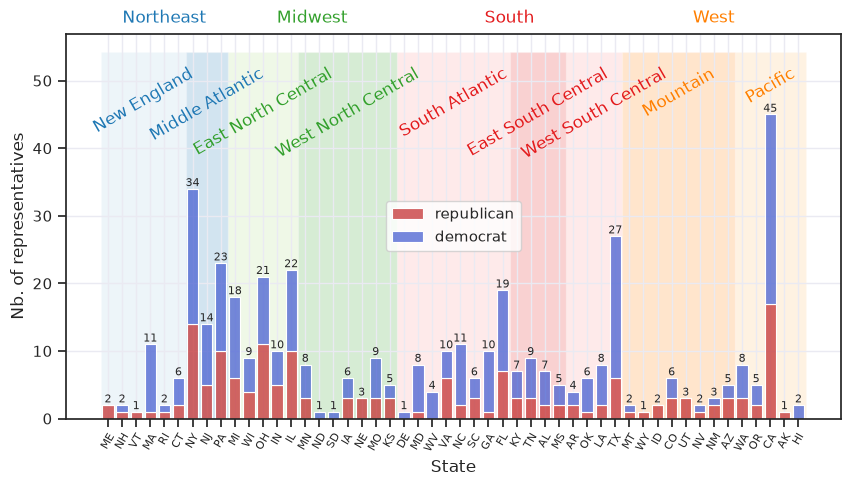

In [17]:
congress_palette = seaborn.color_palette("coolwarm", as_cmap=True)
regions_palette = list(seaborn.color_palette("Paired", n_colors=8).as_hex())

ax = seaborn.histplot(congress_ext_dtf.sort_values(by=["rds_code"]), x="state_abbrev", discrete=True, multiple="stack", shrink=0.8,
                      hue="party", hue_order=["democrat", "republican"], palette=party_to_color);
bar_labels = ["%d" % (ax.containers[0][i].get_height() + ax.containers[1][i].get_height()) for i in range(len(ax.containers[0]))]
ax.bar_label(ax.containers[1], bar_labels, fontsize=8)
ax.set_xlabel("State");
ax.set_ylabel("Nb. of representatives");
ax.tick_params("x", rotation=60, labelsize=8) # , rotation_mode="xtick"
ax.legend(["republican", "democrat"], loc="center");

ybot, ytop = ax.get_ylim()
xpos_states = list(zip(ax.get_xticks(), [t.get_text() for t in ax.get_xticklabels()]))
xpos_regions = []
xpos_divisions = []
rstart = xpos_states[0][0]-0.5
dstart = xpos_states[0][0]-0.5
for i in range(len(xpos_states)-1):
    if i > 0 and reverse_map_divisions[xpos_states[i][1]] != reverse_map_divisions[xpos_states[i+1][1]]:
        dend = (xpos_states[i][0]+xpos_states[i+1][0])/2
        xpos_divisions.append((dstart, dend, reverse_map_divisions[xpos_states[i][1]], len(xpos_regions)))
        dstart = dend
        if reverse_map_regions[xpos_states[i][1]] != reverse_map_regions[xpos_states[i+1][1]]:
            rend = (xpos_states[i][0]+xpos_states[i+1][0])/2
            xpos_regions.append((rstart, rend, reverse_map_regions[xpos_states[i][1]]))
            rstart = rend
xpos_divisions.append((dstart, xpos_states[-1][0]+0.5, reverse_map_divisions[xpos_states[-1][1]], len(xpos_regions)))
xpos_regions.append((rstart, xpos_states[-1][0]+0.5, reverse_map_regions[xpos_states[-1][1]]))

for i, xdiv in enumerate(xpos_divisions):
    ax.fill([xdiv[0], xdiv[0], xdiv[1], xdiv[1]], [ybot, ytop+7, ytop+7, ybot], regions_palette[2*xdiv[-1]+(i%2)], zorder=0, alpha=0.2)
    ax.text((xdiv[0]+xdiv[1])/2, ytop+5, xdiv[2], color=regions_palette[2*xdiv[-1]+1],
            verticalalignment='top', horizontalalignment='center', rotation=30)
for i, xreg in enumerate(xpos_regions):
    ax.text((xreg[0]+xreg[1])/2, ytop+12, xreg[2], color=regions_palette[2*i+1],
            verticalalignment='center', horizontalalignment='center')

We see that California (CA), which belongs to the census division *Pacific* in the census region *West*, is the state with the largest number of representatives, specifically 45, of which a large majority are democrats.

## Mining frequent itemsets

We now move to the actual mining of frequent itemsets.

### Preparing the transactions

But first, we need to turn the dataset into a transactional format, where each row consists of a set of items. In addition to the columns from the *UCI* dataset, which record party affiliation and votes on the sixteen roll calls, we also consider the columns from the complementary dataset which record the age of the representatives as well as geographic information, specifically the represented state, census division and census region.

Age takes numerical values. We discretize it into three buckets using the `pandas.qcut` function. This function determines thresholds to generate three intervals such that each one contains roughly one third of the data points. Because when plotted as a histogram the bins would be represented by three bars of roughly the same height, this is sometimes referred to as *equal-height* binning, as opposed to *equal-width*, where the edges of the bins are equally spaced.

In [18]:
prepare_dtf = congress_dtf.copy()
prepare_dtf["geo-state"] = congress_ext_dtf["state_abbrev"]
prepare_dtf["geo-division"] = congress_ext_dtf["division"]
prepare_dtf["geo-region"] = congress_ext_dtf["region"]
prepare_dtf["age"] = pandas.qcut(1984-congress_ext_dtf["born"], 3)
prepare_dtf

,party,infants,water,budget,physician,el-salvador,religious,satellite,nicaragua,missile,...,synfuels,education,superfund,crime,exports,south-africa,geo-state,geo-division,geo-region,age
0,republican,n,y,n,y,y,y,n,n,n,...,?,y,y,y,n,y,AL,East South Central,South,"(55.0, 84.0]"
1,republican,n,y,n,y,y,y,n,n,n,...,n,y,y,y,n,?,AL,East South Central,South,"(55.0, 84.0]"
2,democrat,?,y,y,?,y,y,n,n,n,...,y,n,y,y,n,n,AL,East South Central,South,"(55.0, 84.0]"
3,democrat,n,y,y,n,?,y,n,n,n,...,y,n,y,n,n,y,AL,East South Central,South,"(55.0, 84.0]"
4,democrat,y,y,y,n,y,y,n,n,n,...,y,?,y,y,y,y,AL,East South Central,South,"(45.0, 55.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,republican,n,n,y,y,y,y,n,n,y,...,n,y,y,y,n,y,WI,East North Central,Midwest,"(29.999, 45.0]"
431,democrat,n,n,y,n,n,n,y,y,y,...,n,n,n,n,n,y,WI,East North Central,Midwest,"(45.0, 55.0]"
432,republican,n,?,n,y,y,y,n,n,n,...,y,y,y,y,n,y,WI,East North Central,Midwest,"(45.0, 55.0]"
433,republican,n,n,n,y,y,y,?,?,?,...,n,y,y,y,n,y,WI,East North Central,Midwest,"(29.999, 45.0]"


As a result, `prepared_dtf` contains twenty-one categorical attributes.

We turn them into Boolean attributes with the `pandas.get_dummies`function. For each value of each categorical attribute, this function creates a new Boolean attribute which is true for rows where the categorical attribute took the associated value and false otherwise.
We name the attributes with the name of the categorical attribute and the value, separated by an underscore.

In [19]:
boolean_dtf = pandas.get_dummies(prepare_dtf, prefix=prepare_dtf.columns)
boolean_dtf

,party_democrat,party_republican,infants_?,infants_n,infants_y,water_?,water_n,water_y,budget_?,budget_n,...,geo-division_South Atlantic,geo-division_West North Central,geo-division_West South Central,geo-region_Midwest,geo-region_Northeast,geo-region_South,geo-region_West,"age_(29.999, 45.0]","age_(45.0, 55.0]","age_(55.0, 84.0]"
0,False,True,False,True,False,False,False,True,False,True,...,False,False,False,False,False,True,False,False,False,True
1,False,True,False,True,False,False,False,True,False,True,...,False,False,False,False,False,True,False,False,False,True
2,True,False,True,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,True
3,True,False,False,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,True
4,True,False,False,False,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,False,True,False,True,False,False,True,False,False,False,...,False,False,False,True,False,False,False,True,False,False
431,True,False,False,True,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,True,False
432,False,True,False,True,False,True,False,False,False,True,...,False,False,False,True,False,False,False,False,True,False
433,False,True,False,True,False,False,True,False,False,True,...,False,False,False,True,False,False,False,True,False,False


As a result, for example attribute `water_n` is true for rows where attribute `water`takes the value `n`, corresponding to representatives who voted *Nay* on the *water* roll call.
Similarly, attribute `age_(45.0, 55.0]` is true for rows where the discretized attribute `age` takes the value `(45.0, 55.0]`, i.e. rows for which the numerical age value falls between 45 (excluded) and 55 (included), corresponding to representatives between 46 and 55 years of age in 1984, representatives born in the years from 1929 to 1938.

Each column will be represented by an item in our transactional dataset, with a value `True` indicating that the item occurs in the corresponding transaction while a value `False` indicates that it does not.

We collect information about the items. By counting the number of true values in each column we can effectively obtain the support count for all individual items.
We associate a `group` tag indicating whether the items corresponds to a vote outcome, party affiliation, age or geographic information.
We show the list of items that constitute our alphabet in this itemset mining task, sorted by decreasing frequency.

In [20]:
items_dtf = pandas.DataFrame(list(zip(boolean_dtf.columns, boolean_dtf.sum(axis=0).values)), columns=["label", "count"])
items_dtf["frequency"] = items_dtf["count"]/boolean_dtf.shape[0]

def get_item_group(label):
    lparts = label.split("_")
    if lparts[-1] == "y":
        return "vote_for"
    if lparts[-1] == "n":
        return "vote_against"
    if lparts[-1] == "?":
        return "vote_abs"
    return lparts[0]
items_dtf["group"] = items_dtf["label"].apply(get_item_group)

items_dtf.sort_values(by="frequency", ascending=False)

,label,count,frequency,group
19,religious_y,272,0.625287,vote_for
49,south-africa_y,269,0.618391,vote_for
0,party_democrat,267,0.613793,party
33,synfuels_n,264,0.606897,vote_against
10,budget_y,253,0.581609,vote_for
...,...,...,...,...
57,geo-state_DE,1,0.002299,geo-state
77,geo-state_ND,1,0.002299,geo-state
99,geo-state_WY,1,0.002299,geo-state
90,geo-state_SD,1,0.002299,geo-state


The two most frequent items are favorable votes, respectively on roll calls *religious*, represented by item id **19** occurring in 272 transactions, and on roll call *south-africa*, represented by item id **49** occurring in 269 transactions.
The third is item id **0**, representing the affiliation to the Democratic party, which occurs in 267 transactions. Indeed we know the dataset contains the votes of 267 democrats.
The least frequent items, which occur in just one transaction each, are those representing states that have a single representative.

We visualize the distribution of frequencies across the items, colored by groups.

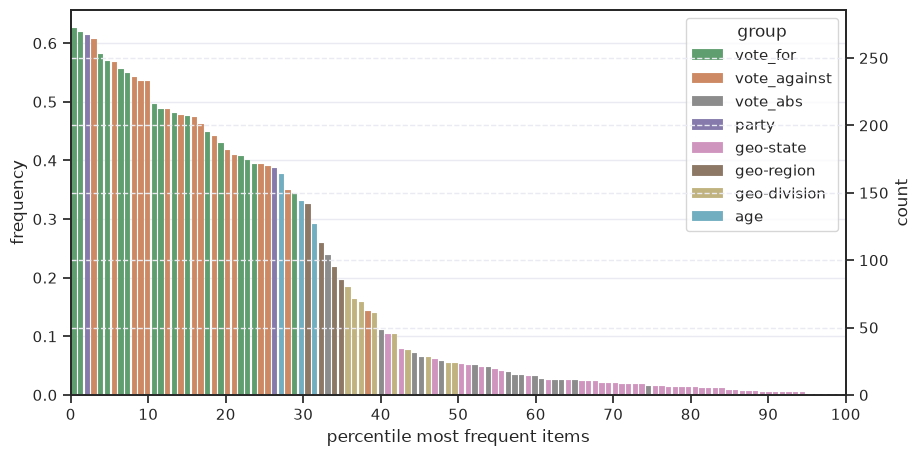

In [21]:
def_colors = seaborn.color_palette().as_hex()
groups_palette = [def_colors[c] for c in [2,1,7,4,6,5,8,9]]
unique_groups = sorted(set(items_dtf["group"]), reverse=True)
(nb_trns, nb_items) = boolean_dtf.shape
ax = seaborn.barplot(items_dtf.sort_values(by="frequency", ascending=False), x="label", y="frequency",
                hue="group", hue_order=unique_groups, palette=groups_palette, linewidth=0.1)
altx = ax.twinx() #delta_zorder=-1
freq_lims = ax.get_ylim()
altx.set_ylim([nb_trns*freq_lims[0], nb_trns*freq_lims[1]])
altx.set_ylabel("count")
altx.grid(linestyle='--')
ax.set_xticks(*zip(*[(nb_items*i/100-0.5, i) for i in range(0,101,10)]));
ax.set_xlabel("percentile most frequent items");

The distribution has a rather long tail, with the ten percent most frequent items occurring each in more than half of the transactions whereas well over half of the items, mostly representing states and vote abstention, occur each in less than ten percent of the transactions.

Finally, we actually turn the Boolean matrix into a transactional dataset by listing for each row the indices of the columns containing value `True`.
As examples, we print the first two and last two obtained transactions.

In [22]:
transactions = [frozenset(map(int, numpy.where(r)[0])) for r in boolean_dtf.to_numpy()]

print("First transaction:      \t", transactions[0])
print("Second transaction:     \t", transactions[1])
print("...")
print("Penultimate transaction:\t", transactions[-2])
print("Last transaction:       \t", transactions[-1])

First transaction:      	 frozenset({1, 3, 7, 9, 13, 16, 19, 21, 24, 27, 31, 32, 37, 40, 43, 45, 49, 51, 101, 111, 115})
Second transaction:     	 frozenset({1, 3, 7, 9, 13, 16, 19, 21, 24, 27, 30, 33, 37, 40, 43, 45, 47, 51, 101, 111, 115})
...
Penultimate transaction:	 frozenset({1, 3, 6, 9, 13, 16, 19, 20, 23, 26, 29, 33, 37, 40, 43, 45, 49, 97, 100, 109, 113})
Last transaction:       	 frozenset({1, 3, 7, 9, 13, 16, 19, 21, 24, 27, 31, 33, 37, 40, 43, 44, 48, 99, 103, 112, 113})


2. <a id="input_2"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the transactions and to explain what they mean.
In particular, how many items does each of the four transactions above contain? Is it a coincidence?
</span>

✏️
...

### First run of the mining algorithm

Now, we are ready to run the frequent itemset mining algorithm on the transactional dataset.

First, we try with a relatively high minimum support threshold of 35%, which means that an itemset is considered frequent if it occurs in at least $\lceil 0.35 \times 435 \rceil = 153$ transactions.

In [23]:
%%time
nb_tot = len(transactions)
FI = fim(transactions, supp=35)
print(f"Found {len(FI)} itemsets")

Found 322 itemsets
CPU times: user 7.34 ms, sys: 0 ns, total: 7.34 ms
Wall time: 7.32 ms


More than three hundred frequent itemsets were mined in fractions of a second.

Let us have a look at first ten returned itemsets.

In [24]:
FI[:10]

[((113,), 164),
 ((1, 16, 13), 156),
 ((1, 16), 157),
 ((1, 43, 13), 155),
 ((1, 43), 158),
 ((1, 13), 163),
 ((1,), 168),
 ((42, 15), 153),
 ((42, 10, 12, 0), 156),
 ((42, 10, 12), 156)]

The results come as a list of pairs. Each pair represents a frequent itemset, where the first element is a tuple of the indices of items constituting the itemset while the second element is the support count of the itemset. For instance, the first listed itemset is a singleton consisting of just item **113**, occurring in 164 transactions, whereas the fourth listed itemset contains three items, **1**, **16** and **13**, which occur together in 156 transactions.

In [25]:
print("The longest frequent itemset contains %d items." % numpy.max([len(fi[0]) for fi in FI]))

The longest frequent itemset contains 6 items.


We can use the item information collected in `items_dtf` to recover the item labels for the indices. For example, for the first listed itemset.

In [26]:
[items_dtf.at[i, "label"] for i in FI[0][0]]

['age_(29.999, 45.0]']

The first listed itemset consists of just item `age_(29.999, 45.0]`, its support set consists of the ids of transactions corresponding to the hundred and sixty-four representatives 45 years old or younger.

And similarly for the second listed itemset.

In [27]:
[items_dtf.at[i, "label"] for i in FI[1][0]]

['party_republican', 'el-salvador_y', 'physician_y']

3. <a id="input_3"></a><span style="background-color:#FEDA8B;">
Write a sentence to explain what this itemset represents.
</span>

✏️
...

We write a function to display the basic details of a given itemset, that is, its absolute support (count), relative support (frequency), size (as the number of items it contains), along with the itemset as a list of item ids and as a list of item labels.

In [28]:
def disp_fi(fi, items_dtf, preff_last_col="", preff="", suff=""):
    itemset_ids = ", ".join(map(str, fi[0]))
    itemset_labels = ", ".join([items_dtf.at[x, "label"] for x in fi[0]])
    print(f"{preff}{fi[1]: 3d}\t{fi[1]/nb_tot:.3f}\t{len(fi[0]):d}\t{itemset_ids:>30}{preff_last_col}\t{itemset_labels}{suff}")

We sort the obtained itemsets by decreasing support and use our function to display the first five and last five.

In [29]:
FI_sorted = sorted(FI, key=lambda x: -x[1])
for fi in FI_sorted[:5]:
    disp_fi(fi, items_dtf)
print("...")
for fi in FI_sorted[-5:]:
    disp_fi(fi, items_dtf)

 272	0.625	1	                            19	religious_y
 269	0.618	1	                            49	south-africa_y
 267	0.614	1	                             0	party_democrat
 264	0.607	1	                            33	synfuels_n
 253	0.582	1	                            10	budget_y
...
 153	0.352	3	                    28, 36, 22	missile_y, education_n, satellite_y
 153	0.352	4	                28, 36, 12, 25	missile_y, education_n, physician_n, nicaragua_y
 153	0.352	5	             28, 15, 22, 12, 0	missile_y, el-salvador_n, satellite_y, physician_n, party_democrat
 153	0.352	4	                40, 16, 19, 43	superfund_y, el-salvador_y, religious_y, crime_y
 153	0.352	3	                     10, 49, 0	budget_y, south-africa_y, party_democrat


The five most frequent itemsets are singleton itemsets, itemsets that consist of a single item. This is expected, due to the downward closure property of support.
Indeed, according to this property, if we consider an itemset *I*, the support count of any itemset *J* which is a superset of *I* is at most as high as the support count of *I*. Simply put, adding an item to an itemset can only reduce the support count or leave it unchanged.

Singleton itemsets are of limited interest, in the sense that we already have their support count listed in `items_dtf`, they do not bring us any new information.

The last itemsets in the sorted results each occur in 153 transactions, just often enough to be considered frequent, they combine three, four or five items.

We use our function to display five itemsets selected at random from this first returned collection.

In [30]:
for i in RNG.choice(len(FI), 5, replace=False):
    disp_fi(FI[i], items_dtf)

 156	0.359	5	             15, 36, 10, 12, 0	el-salvador_n, education_n, budget_y, physician_n, party_democrat
 158	0.363	2	                        42, 10	crime_n, budget_y
 158	0.363	5	             36, 22, 12, 25, 0	education_n, satellite_y, physician_n, nicaragua_y, party_democrat
 245	0.563	2	                         12, 0	physician_n, party_democrat
 174	0.400	3	                    28, 12, 25	missile_y, physician_n, nicaragua_y


4. <a id="input_4"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the displayed itemsets and to explain what they mean.
Make sure your statement agrees with the output after changing the random seed.
</span>

✏️
...

### Running the mining algorithm with different parameters

We run the mining algorithm with the same minimum support threshold of 35%, but setting the `target` parameter to 'c' instead of its default value 's', which means that the algorithm will return only the closed frequent itemsets instead of all frequent itemsets.

Recall that an itemset is a *closed itemset* if none of its supersets has the same support.

In [31]:
%%time
nb_tot = len(transactions)
FIc = fim(transactions, target="c", supp=35)
print(f"Found {len(FIc)} itemsets")

Found 300 itemsets
CPU times: user 7.12 ms, sys: 2 μs, total: 7.12 ms
Wall time: 7.1 ms


The number of returned itemsets went from 322 to 300, meaning that only 22 of the frequent itemsets at minimum support threshold 35% are not closed, that is, only 22 of these frequent itemsets have at least one superset with the same support. The vast majority of the found frequent itemsets are closed.

We run the mining algorithm once again with the same minimum support threshold of 35%, but this time setting the `target` parameter to 'm', so that the algorithm will return only  the maximal frequent itemsets.

Recall that an itemset is a *maximal frequent itemset* if it is frequent and none of its supersets is frequent. Note that this means that none of its supersets has the same support. In other words, if an itemset is a *maximal frequent itemset*, then it is a *closed itemset*. However, the converse is not true in general.

The maximal frequent itemsets form the border of frequent itemsets in the itemset lattice.

In [32]:
%%time
FIm = fim(transactions, target="m", supp=35)
print(f"Found {len(FIm)} itemsets")

Found 75 itemsets
CPU times: user 14.7 ms, sys: 0 ns, total: 14.7 ms
Wall time: 14.5 ms


The number of returned itemsets dropped to 75, less than a quarter of all frequent itemsets at this minimum support threshold.

Given a minimum support threshold, the collection of closed frequent itemsets along with their support counts are seen as a lossless compression of the frequent itemsets.
For any itemset, we can determine whether it is frequent by checking whether any of its supersets (including the itemset itself) belongs to the collection of closed frequent itemsets.
Furthermore, if the itemset is indeed frequent, we can determine its support count exactly, as the minimum support count over those of its supersets (including the itemset itself) that belong to the collection of closed frequent itemsets.

Given a minimum support threshold, the collection of closed frequent itemsets along with their support counts are seen as a lossy compression of the frequent itemsets.
For any itemset, we can determine whether it is frequent by checking whether any of its supersets (including the itemset itself) belongs to the collection of maximal frequent itemsets. However, we can obtain a lower bound on the support count of the itemset, as the minimum support count over those of its supersets (including the itemset itself) that belong to the collection of closed frequent itemsets, but we cannot always determine its support count exactly.

In this case, as is often the case, the vast majority of the found frequent itemsets are closed, so the compression afforded by dropping the frequent itemsets that are not closed is rather poor.
On the other hand, while 75 itemsets is still quite many to peruse, the maximal frequent itemsets provide a more compact, albeit lossy, representation of the frequent itemsets.

We visualize the distribution of support counts among all frequent itemsets (top) and among only the subset of maximal frequent itemsets (bottom). We use different colors to represent itemsets of different sizes, i.e. containing different numbers of items.
Note that we turn the sizes to strings to prevent the plotting function from processing them as numerical values, giving us more control on how they are handled, e.g. in what order they are stacked.

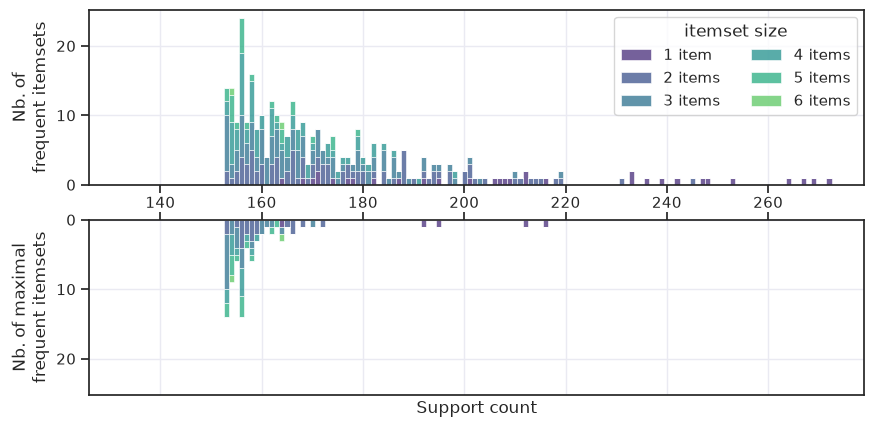

In [33]:
f, axes = plt.subplots(2, 1, sharex=True)
seaborn.histplot(x=[fi[1] for fi in FI], hue=[str(len(fi[0])) for fi in FI], multiple='stack', discrete=True,
                      hue_order=map(str, range(7,0,-1)), palette="viridis_r", ax=axes[0])
seaborn.histplot(x=[fi[1] for fi in FIm], hue=[str(len(fi[0])) for fi in FIm], multiple='stack', discrete=True,
                      hue_order=map(str, range(7,0,-1)), palette="viridis_r", ax=axes[1], legend=False)
axes[0].legend(["%d item%s" % (i, "s" if i > 1 else "") for i in range(1, 8)], title="itemset size", ncols=2)
axes[1].set_xlim([126, 279])
axes[1].set_ylim(axes[0].get_ylim()[::-1])
axes[1].tick_params("x", bottom=False, top=True, labeltop=True, labelbottom=False, labelright=True, pad=0)
axes[1].set_xlabel("Support count");
axes[0].set_ylabel("Nb. of\nfrequent itemsets");
axes[1].set_ylabel("Nb. of maximal\nfrequent itemsets");

As expected, no frequent itemset has a support count below 153. The itemsets with highest support counts are mainly singleton itemsets.
We notice a peak, corresponding to more than 20 itemsets having a support count of 156.

We list those itemsets having a support count of 156 transactions, then list the itemsets with a support count equal to the minimum support threshold of 153 transactions, prefixing the maximal frequent itemsets with 'MAX'.

In [34]:
def disp_fis_max(FIall, FImax, supp_count, items_dtf):
    max_its = set([fi[0] for fi in FImax if fi[1] == supp_count])
    i = 0
    for fi in FIall:
        if fi[1] == supp_count:
            i += 1
            disp_fi(fi, items_dtf, preff=f"{i: 3d})\tMAX\t" if fi[0] in max_its else f"{i: 3d})\t   \t")

print("## Support count = 156")
disp_fis_max(FI, FIm, 156, items_dtf)
print()
print("## Support count = 153")
disp_fis_max(FI, FIm, 153, items_dtf)

## Support count = 156
  1)	MAX	 156	0.359	3	                     1, 16, 13	party_republican, el-salvador_y, physician_y
  2)	MAX	 156	0.359	4	                 42, 10, 12, 0	crime_n, budget_y, physician_n, party_democrat
  3)	   	 156	0.359	3	                    42, 10, 12	crime_n, budget_y, physician_n
  4)	MAX	 156	0.359	4	                 42, 25, 12, 0	crime_n, nicaragua_y, physician_n, party_democrat
  5)	   	 156	0.359	3	                    42, 25, 12	crime_n, nicaragua_y, physician_n
  6)	MAX	 156	0.359	3	                    13, 19, 16	physician_y, religious_y, el-salvador_y
  7)	   	 156	0.359	3	                    24, 19, 43	nicaragua_n, religious_y, crime_y
  8)	MAX	 156	0.359	2	                        21, 27	satellite_n, missile_n
  9)	MAX	 156	0.359	3	                    21, 16, 19	satellite_n, el-salvador_y, religious_y
 10)	MAX	 156	0.359	2	                          4, 0	infants_y, party_democrat
 11)	   	 156	0.359	4	                 39, 15, 12, 0	superfund_n, el-salvador

In this case, all itemsets with support count of 153 transactions (second list) are maximal frequent itemsets. More than half of the twenty-four itemsets with a support count of 156 transactions (first list) are also maximal frequent itemsets.

The third itemset of the first list, (**42**, **10**, **12**) is not maximal frequent, indeed it is a subset of the itemset listed just above (**42**, **10**, **12**, **0**), which has the same support count of 156.
Consider the eleventh itemset of the first list, (**39**, **15**, **12**, **0**), with support count 156 transactions. None of its supersets has the same support (none of the 5-itemsets listed contains both items **39** and **15**), so it is a closed itemset, but one of its supersets, (**39**, **15**, **12**, **25**, **0**) has support count 153 (fifth itemset in the second list), so it is not a maximal frequent itemset.
Finally, the twenty-second itemset of the first list, (**36**, **22**, **10**, **12**) is also not maximal frequent, but none of its superset appears in either the first or the second list. It must have a superset with an intermediate support count, either 155 or 154 transactions.

We run the mining algorithm again, lowering the minimum support threshold from 35% to 30%, which means that an itemset is now considered frequent if it occurs in at least $\lceil 0.30 \times 435 \rceil = 131$ transactions.
First, we set the `target` parameter to 's' to obtain all frequent itemsets.

In [35]:
%%time
nb_tot = len(transactions)
FI30 = fim(transactions, target="s", supp=30)
print(f"Found {len(FI30)} itemsets")

Found 976 itemsets
CPU times: user 14.1 ms, sys: 3 μs, total: 14.1 ms
Wall time: 14 ms


Although the minimum support threshold is only five percentage points lower, or about twenty transactions, almost three times as many itemsets are now frequent.

Note that any itemsets that is frequent at a given support threshold is also frequent at a lower support threshold, since its support count, being above the higher threshold is also clearly above the lower one. As a consequence the collection of frequent itemsets found with the lower support threshold is a superset of the collection of frequent itemsets found with the higher threshold.
Also, as we lower the support threshold, the number of frequent itemsets cannot decrease.

This is one tricky aspect of setting the minimum support threshold, the number of frequent itemsets does not grow linearly as the minimum support threshold is lowered.
If the threshold is set too high, we will not find any frequent itemset, whereas if it is set too low, we will be flooded with them.

In [36]:
print("The longest frequent itemset contains %d items." % numpy.max([len(fi[0]) for fi in FI30]))

The longest frequent itemset contains 7 items.


The additional frequent itemsets include some that contain seven items.

We run the mining algorithm again with the lower minimum support threshold of 30%, but setting the `target` parameter to 'm' to obtain only the maximal frequent itemsets.

Note that we run the algorithm again by pure convenience. We could instead filter the collection of all frequent itemsets and keep only those that we determine are maximal frequent itemsets.

In [37]:
%%time
FIm30 = fim(transactions, target="m", supp=30)
print(f"Found {len(FIm30)} itemsets")

Found 182 itemsets
CPU times: user 30.6 ms, sys: 0 ns, total: 30.6 ms
Wall time: 30.5 ms


The number of maximal frequent itemsets also increased notably as we lowered the minimum support threshold, but not as sharply as the overall number of frequent itemsets.

We visualize again the distribution of support counts among all frequent itemsets (top) and among only the subset of maximal frequent itemsets (bottom), with different colors for itemsets of different sizes, now for the lower minimum support threshold.

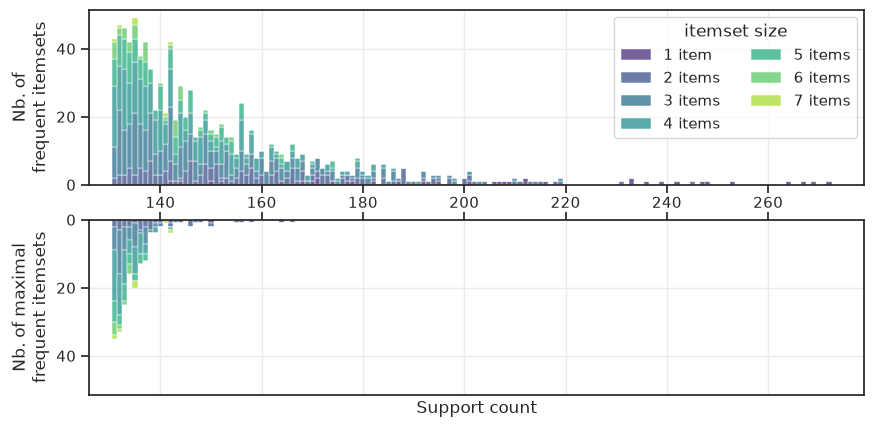

In [38]:
f, axes = plt.subplots(2, 1, sharex=True)
seaborn.histplot(x=[fi[1] for fi in FI30], hue=[str(len(fi[0])) for fi in FI30], multiple='stack', discrete=True,
                      hue_order=map(str, range(7,0,-1)), palette="viridis_r", ax=axes[0])
seaborn.histplot(x=[fi[1] for fi in FIm30], hue=[str(len(fi[0])) for fi in FIm30], multiple='stack', discrete=True,
                      hue_order=map(str, range(7,0,-1)), palette="viridis_r", ax=axes[1], legend=False)
axes[0].legend(["%d item%s" % (i, "s" if i > 1 else "") for i in range(1, 8)], title="itemset size", ncols=2)
axes[1].set_xlim([126, 279])
axes[1].set_ylim(axes[0].get_ylim()[::-1])
axes[1].tick_params("x", bottom=False, top=True, labeltop=True, labelbottom=False, labelright=True, pad=0)
axes[1].set_xlabel("Support count");
axes[0].set_ylabel("Nb. of\nfrequent itemsets");
axes[1].set_ylabel("Nb. of maximal\nfrequent itemsets");

Since the collection of frequent itemsets at this lower minimum support threshold is a superset of those found with the previous minimum support threshold, the histogram in the top panel is the same as the previous one, with additional bars on the left, at support count values between 131 and 153, representing the additional frequent itemsets.
Note the different scale on the vertical axis, reflecting the larger number of frequent itemsets. Many more itemsets have a support count between 131 and 153 than above.

The collection of maximal frequent itemsets at this lower minimum support threshold is a subset of the frequent itemsets found with this same support threshold, but it is not a superset of the collection of maximal frequent itemsets found with the higher minimum support threshold.
Indeed, considering an itemset that was maximal frequent at the higher minimum support threshold, if any of its supersets has a support count between 131 and 153, that superset is now considered frequent and the original itemset is no longer maximal frequent.

We also note that the maximal frequent itemsets have support counts close to the minimum support threshold. This means that in most cases, for a given itemset, there exists some item such that, when added to the itemset, the support will be reduced by just a few transactions rather than falling dramatically.

We list the itemsets with a support count equal to the minimum support threshold of 131 transactions, prefixing the maximal frequent itemsets with 'MAX'.

In [39]:
disp_fis_max(FI30, FIm30, 131, items_dtf)

  1)	MAX	 131	0.301	2	                        18, 36	religious_n, education_n
  2)	MAX	 131	0.301	3	                    18, 12, 15	religious_n, physician_n, el-salvador_n
  3)	MAX	 131	0.301	4	                 18, 0, 15, 25	religious_n, party_democrat, el-salvador_n, nicaragua_y
  4)	MAX	 131	0.301	4	                 1, 24, 13, 16	party_republican, nicaragua_n, physician_y, el-salvador_y
  5)	MAX	 131	0.301	4	                 1, 37, 16, 13	party_republican, education_y, el-salvador_y, physician_y
  6)	   	 131	0.301	3	                     1, 37, 16	party_republican, education_y, el-salvador_y
  7)	MAX	 131	0.301	4	                  1, 9, 27, 13	party_republican, budget_n, missile_n, physician_y
  8)	MAX	 131	0.301	4	                  1, 9, 27, 16	party_republican, budget_n, missile_n, el-salvador_y
  9)	MAX	 131	0.301	4	                  1, 9, 43, 16	party_republican, budget_n, crime_y, el-salvador_y
 10)	MAX	 131	0.301	4	                 42, 39, 25, 0	crime_n, superfund_n, nicaragua_y

5. <a id="input_5"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the listed itemsets and to explain what they mean.
</span>

✏️
...

Last, we run the mining algorithm with a completely different set of parameters, looking for long closed itemsets. That is, we set the `target` parameter to 'c' and constrain the number of items in the returned itemset to be between ten and twelve, using parameters `zmin` and `zmax`. Given these constraints, we set the minimum support threshold rather low.
Negative values for the `supp` parameter are interpreted as absolute support.
Here, for instance, we set this parameter to -70, meaning that an itemset is considered frequent if it occurs in a least seventy transactions. This corresponds to a relative support of sixteen percent, since $\lceil 0.16 \times 435 \rceil = 70$

In [40]:
%%time
FIlong = fim(transactions, target="c", zmin=10, zmax=12, supp=-70)
print(f"Found {len(FIlong)} itemsets")

Found 736 itemsets
CPU times: user 133 ms, sys: 4 μs, total: 133 ms
Wall time: 133 ms


We obtained almost two hundred frequent closed itemsets satisfying the size constraints.

We sort the obtained itemsets by decreasing frequency and display the first five as well as the last five.

In [41]:
FIlong_sorted = sorted(FIlong, key=lambda x: -x[1])
for fi in FIlong_sorted[:5]:
    disp_fi(fi, items_dtf, preff_last_col="\n\t")
print("...")
for fi in FIlong_sorted[-5:]:
    disp_fi(fi, items_dtf, preff_last_col="\n\t")

 94	0.216	10	1, 21, 45, 24, 43, 19, 9, 16, 27, 13
		party_republican, satellite_n, exports_n, nicaragua_n, crime_y, religious_y, budget_n, el-salvador_y, missile_n, physician_y
 94	0.216	10	1, 24, 40, 9, 45, 43, 19, 16, 27, 13
		party_republican, nicaragua_n, superfund_y, budget_n, exports_n, crime_y, religious_y, el-salvador_y, missile_n, physician_y
 92	0.211	10	1, 21, 40, 9, 24, 43, 19, 16, 27, 13
		party_republican, satellite_n, superfund_y, budget_n, nicaragua_n, crime_y, religious_y, el-salvador_y, missile_n, physician_y
 92	0.211	10	1, 24, 37, 9, 45, 43, 19, 16, 27, 13
		party_republican, nicaragua_n, education_y, budget_n, exports_n, crime_y, religious_y, el-salvador_y, missile_n, physician_y
 91	0.209	10	1, 21, 40, 45, 24, 19, 9, 16, 27, 13
		party_republican, satellite_n, superfund_y, exports_n, nicaragua_n, religious_y, budget_n, el-salvador_y, missile_n, physician_y
...
 70	0.161	10	37, 21, 33, 40, 45, 24, 27, 19, 16, 13
		education_y, satellite_n, synfuels_n, superfund_y, 

6. <a id="input_6"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the listed itemsets and to explain what they mean.
In particular, are there common items recurring among these itemsets?
</span>

✏️
...

## Further analysis

Next, we mine a large collection of frequent itemsets, which we will then study in more details, focusing on different characteristics in turn.

### Mining a large collection of itemsets

We run the mining algorithm with a fairly low minimum support threshold of 70 transactions and the `target` parameter set to 's', to obtain all frequent itemsets.

In [42]:
%%time
FIa70 = fim(transactions, target="s", supp=-70)
print(f"Found {len(FIa70)} itemsets")

Found 27799 itemsets
CPU times: user 124 ms, sys: 5.01 ms, total: 129 ms
Wall time: 129 ms


The algorithm returned tens of thousands of itemsets in less than a second. Clearly, it is infeasible examine and interpret each itemset individually.

We tabulate the results, with one itemset per row and columns for the itemset represented as a list of numerical item ids in the order in which it was mined (`itemset_org`), as a list of numerical item ids sorted increasingly (`itemset_ids`), as a list of item labels (`itemset_labels`), followed by columns for the number of items that constitute the itemset (`itemset_size`), as well as the support of the itemset as an absolute value (`support_count`) and as a fractional value (`support_relative`).

In [43]:
%%time
L = [[fi[0], tuple(sorted(fi[0])), tuple([items_dtf.at[x, "label"] for x in sorted(fi[0])]), len(fi[0]), fi[1], fi[1]/nb_tot] for fi in FIa70]
FIa70_dtf = pandas.DataFrame(L, columns=["itemset_org", "itemset_ids", "itemset_labels", "itemset_size", "support_count", "support_relative"])
print(f"Processed {FIa70_dtf.shape[0]} itemsets")

Processed 27799 itemsets
CPU times: user 1.52 s, sys: 5.01 ms, total: 1.53 s
Wall time: 1.53 s


We count the number of itemsets of each size.

In [44]:
FIa70_dtf["itemset_size"].value_counts().sort_index()

itemset_size
1       43
2      450
3     1483
4     3110
5     4752
6     5666
7     5339
8     3892
9     2109
10     774
11     163
12      17
13       1
Name: count, dtype: int64

Forty-three of the 116 singleton itemsets and 450 out of their $(43 \cdot 42)/2=903$ two-items combinations occur in 70 transactions or more.
The number of distinct frequent itemsets increases sharply with the size, reaches a peak value of 5666 frequent six-itemsets, then decreases sharply and ends with a single itemset of size 13.

Considering only the 43 items that constitute a frequent singleton itemset when taken individually, we can build
$$C(43, 6) = \frac{43!}{(43-6)! \cdot 6!} = \frac{43 \cdot 42 \cdot 41 \cdot 40 \cdot 39 \cdot 38}{6 \cdot 5 \cdot 4 \cdot 3 \cdot 2 \cdot 1} = 43 \cdot 7 \cdot 41 \cdot 1 \cdot 13 \cdot 38 = 6096454$$ distinct combinations of six items. Only a small fraction of them occurs in the transactions, and a smaller fraction still occurs in more than 70 transactions and are hence considered frequent here, namely 5666.
It would not be feasible to generate all combinations of items and count their support to determine which ones are frequent. Clearly, we need to use more methodical and careful approach, like the strategy implemented in the mining algorithm that we use.

For visualization, we group the smallest and largest sizes, which correspond to the fewest itemsets, obtaining seven bins as balanced as possible.

In [45]:
FIa70_dtf["itemset_size_binned"] = pandas.cut(FIa70_dtf["itemset_size"], [0.]+list(range(3,9))+[14.])
FIa70_dtf["itemset_size_binned"].value_counts().sort_index()

itemset_size_binned
(0.0, 3.0]     1976
(3.0, 4.0]     3110
(4.0, 5.0]     4752
(5.0, 6.0]     5666
(6.0, 7.0]     5339
(7.0, 8.0]     3892
(8.0, 14.0]    3064
Name: count, dtype: int64

We plot the distribution of frequent itemsets by support count, grouped by itemset size.

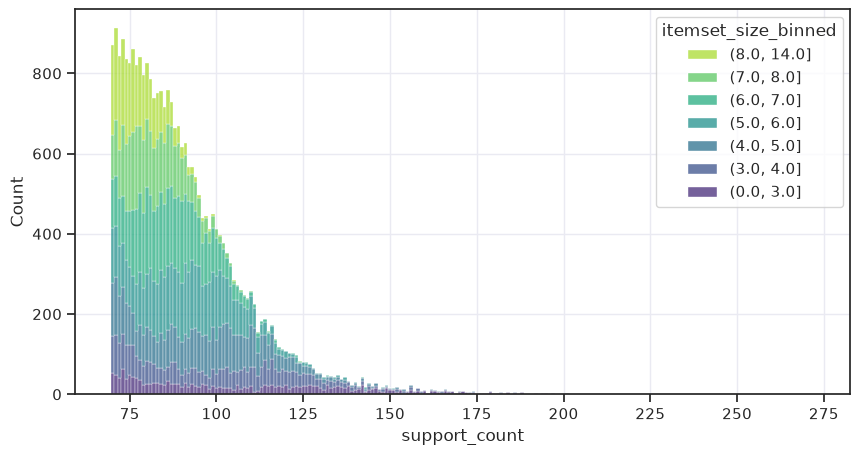

In [46]:
size_palette = "viridis_r"
size_order = FIa70_dtf["itemset_size_binned"].values.categories.values[::-1]
ax = seaborn.histplot(FIa70_dtf, x="support_count", hue="itemset_size_binned", multiple='stack', discrete=True,
                      hue_order=size_order, palette=size_palette)

7. <a id="input_7"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe the distribution of itemsets with respect to support count and size.
</span>

✏️
...

### Studying itemset closure

Next, we will study itemset closure, i.e. which itemsets are closed, which ones are not, and whether they display specific characteristics.

For this purpose, we need to determine for each of our collected frequent itemsets whether it is closed.
To do so, for a given itemset we need to compare the support counts of its supersets to the support count of the itemset itself. Hence, we need a quick access to the support count of itemsets, so we create a dictionary mapping itemsets to their support count.

In [47]:
FIa70_supports =  dict(FIa70_dtf[["itemset_ids", "support_count"]].values)

We also need to list the supersets of a given itemset, and more specifically its direct supersets, that is, all itemsets obtained by adding a new item.
We write a function `get_direct_supersets_ids` for this purpose. It takes as input parameters an itemset as a tuple of numerical item ids (`itemset`) along with the last numerical item id on the alphabet (`last_i`). It returns all the supersets of the itemset, each as a tuple of numerical item ids, which we can use to index the dictionary of support counts, along with the additional item used to build the superset.

In [48]:
def get_direct_supersets_ids(itemset, last_i):
    if len(itemset) == 0:
        for i in range(last_i+1):
            yield ((i,), i)
    else:
        for i in range(itemset[0]):
            yield ((i,)+itemset, i)
        for j in range(1, len(itemset)):
            for i in range(itemset[j-1]+1, itemset[j]):
                yield (itemset[:j]+(i,)+itemset[j:], i)
        for i in range(itemset[-1]+1, last_i+1):
            yield (tuple(itemset)+(i,), i)

We combine the support dictionary and the function generating supersets to determine whether each of the collected frequent itemset is frequent.
In particular, we generate the supersets of the considered itemset and query their support count. We keep track of the additional items that produce supersets whose support count is equal to that of the considered itemset. Intuitively, these items cause the itemset not to be closed, so we dub such items 'open items'.

An itemset is closed if none of its superset has the same support. Hence, in this case, a considered itemset is closed if and only if the associated list of 'open items' is empty.

Note that if an itemset is not in the dictionary, it means that it was not among the frequent itemsets or, in other words, that its support count was strictly below 70 transactions, and hence strictly below the support count of any itemset in our table. For our purpose of determining whether the itemsets in our table are closed, it does not matter what the exact support count of such infrequent itemset is. When an itemset is not in the dictionary, we might return any value strictly less than 70, in particular, we return 0.

In [49]:
%%time
last_i = items_dtf.shape[0]-1
FIa70_dtf["open_items"] = FIa70_dtf.apply(lambda elem:
            tuple([si for (superset, si) in get_direct_supersets_ids(elem["itemset_ids"], last_i)
                   if FIa70_supports.get(superset, 0) == elem["support_count"]]),
                                        axis=1)
FIa70_dtf["closed"] = FIa70_dtf.apply(lambda elem: len(elem["open_items"]) == 0, axis=1)
print(f"Processed {FIa70_dtf.shape[0]} itemsets")

Processed 27799 itemsets
CPU times: user 3.24 s, sys: 4.99 ms, total: 3.24 s
Wall time: 3.24 s


In [50]:
FIa70_dtf["closed"].value_counts()

closed
True     18437
False     9362
Name: count, dtype: int64

Nearly two thirds of the frequent itemsets are closed.

We plot the distribution of frequent itemsets by support count, separately for itemsets that are closed (top) and that are not (bottom).

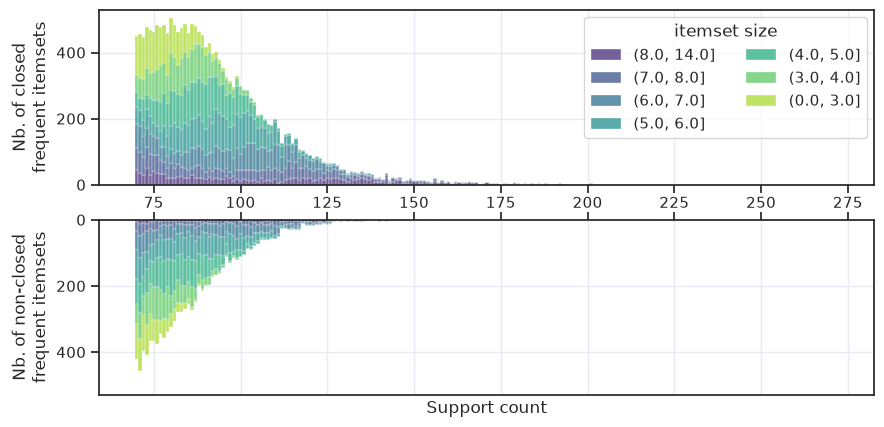

In [51]:
f, axes = plt.subplots(2, 1, sharex=True)
size_palette = "viridis_r"
seaborn.histplot(FIa70_dtf.loc[FIa70_dtf["closed"]==True], x="support_count", hue="itemset_size_binned", multiple='stack', discrete=True,
                      hue_order=size_order, palette=size_palette, ax=axes[0])
seaborn.histplot(FIa70_dtf.loc[FIa70_dtf["closed"]==False], x="support_count", hue="itemset_size_binned", multiple='stack', discrete=True,
                      hue_order=size_order, palette=size_palette, ax=axes[1], legend=False)
axes[0].legend([lt.get_text() for lt in axes[0].get_legend().get_texts()], title="itemset size", ncols=2)
axes[1].set_ylim(axes[0].get_ylim()[::-1])
axes[1].tick_params("x", bottom=False, top=True, labeltop=True, labelbottom=False, labelright=True, pad=0)
axes[1].set_xlabel("Support count");
axes[0].set_ylabel("Nb. of closed\nfrequent itemsets");
axes[1].set_ylabel("Nb. of non-closed\nfrequent itemsets");

8. <a id="input_8"></a><span style="background-color:#FEDA8B;">
Write a few sentences to compare the distribution of itemsets with respect to support count and size for closed versus non-closed itemsets.
</span>

✏️
...

We take a closer look at the 'open items'.

In [52]:
FIa70_dtf["open_items"].value_counts()

open_items
()             18437
(13,)           3705
(0,)            2322
(12,)           1202
(1,)             762
(0, 12)          559
(25,)            300
(0, 25)          143
(12, 25)         119
(1, 13)           88
(0, 12, 25)       41
(15,)             40
(16,)             32
(0, 15)           28
(12, 15)           7
(0, 12, 15)        7
(43,)              3
(110,)             1
(109,)             1
(15, 25)           1
(0, 15, 25)        1
Name: count, dtype: int64

There are few different such items, that when added to some itemset do not alter its support.

In [53]:
open_items_counts = FIa70_dtf["open_items"].value_counts()
open_items_list = list(set().union(*open_items_counts.index.values))
print(f"There are {len(open_items_list)} distinct open items, details are listed below.")
items_dtf.iloc[open_items_list]

There are 10 distinct open items, details are listed below.


,label,count,frequency,group
0,party_democrat,267,0.613793,party
1,party_republican,168,0.386207,party
43,crime_y,248,0.570115,vote_for
12,physician_n,247,0.567816,vote_against
13,physician_y,177,0.406897,vote_for
110,geo-region_Northeast,95,0.218391,geo-region
15,el-salvador_n,208,0.478161,vote_against
16,el-salvador_y,212,0.487356,vote_for
109,geo-region_Midwest,113,0.259770,geo-region
25,nicaragua_y,242,0.556322,vote_for


In [54]:
for i in open_items_list:
    nb_involving_i = [v for k,v in open_items_counts.items() if i in k]
    print("% 4d\t% 6d = %s" % (i, sum(nb_involving_i), " + ".join(map(str, nb_involving_i))))

   0	  3101 = 2322 + 559 + 143 + 41 + 28 + 7 + 1
   1	   850 = 762 + 88
  43	     3 = 3
  12	  1935 = 1202 + 559 + 119 + 41 + 7 + 7
  13	  3793 = 3705 + 88
 110	     1 = 1
  15	    84 = 40 + 28 + 7 + 7 + 1 + 1
  16	    32 = 32
 109	     1 = 1
  25	   605 = 300 + 143 + 119 + 41 + 1 + 1


For example, there are 3101 frequent itemsets such that when item id **0** is added, the support does not change. Item id **0** represents the affiliation to the Democratic Party, so this means there are 3101 combinations of items, not involving party affiliation, that are specific to the representatives from the democrats, i.e. that occur only for democrats, not for any republican, so that when item id **0** is added no republican is dropped from the support and it remains unchanged.
The affiliation to the Republican Party, item id **1**, is also among the 'open items' for a smaller but still substantial number of itemsets (850).
Votes in favor and against on the *physician* roll call, represented respectively by item ids **13** and **12**, are both among 'open items' for thousands of itemsets, often along affiliation with the republicans and with the democrats, respectively.

Let us check the support count of the itemset that consists of the three items with ids **0**, **12** and **25**.

In [55]:
FIa70_dtf[FIa70_dtf["itemset_ids"] == (0,12,25)]

,itemset_org,itemset_ids,itemset_labels,itemset_size,support_count,support_relative,itemset_size_binned,open_items,closed
27735,"(25, 12, 0)","(0, 12, 25)","(party_democrat, physician_n, nicaragua_y)",3,210,0.482759,"(0.0, 3.0]",(),True


This itemset has a support count of 210, which means that 210 representatives are affiliated with the Democratic Party (item id **0**), voted against on the *physician* roll call (item id **12**) and in favor on the *nicaragua* roll call (item id **25**).

We display a few of the itemsets for which all three of these items are listed as 'open items'.

In [56]:
FIa70_dtf.loc[FIa70_dtf["open_items"]==(0,12,25)].head()

,itemset_org,itemset_ids,itemset_labels,itemset_size,support_count,support_relative,itemset_size_binned,open_items,closed
255,"(18, 30, 10, 22, 15)","(10, 15, 18, 22, 30)","(budget_y, el-salvador_n, religious_n, satelli...",5,70,0.160920,"(4.0, 5.0]","(0, 12, 25)",False
319,"(18, 33, 42, 10)","(10, 18, 33, 42)","(budget_y, religious_n, synfuels_n, crime_n)",4,70,0.160920,"(3.0, 4.0]","(0, 12, 25)",False
327,"(18, 33, 42, 22)","(18, 22, 33, 42)","(religious_n, satellite_y, synfuels_n, crime_n)",4,70,0.160920,"(3.0, 4.0]","(0, 12, 25)",False
335,"(18, 33, 42, 15)","(15, 18, 33, 42)","(el-salvador_n, religious_n, synfuels_n, crime_n)",4,71,0.163218,"(3.0, 4.0]","(0, 12, 25)",False
343,"(18, 33, 42)","(18, 33, 42)","(religious_n, synfuels_n, crime_n)",3,72,0.165517,"(0.0, 3.0]","(0, 12, 25)",False


The first one, itemset (**18**, **33**, **42**), which occurs in 72 transactions, means that all 72 representatives who voted against on the *religious* roll call (item id **18**), the *synfuel* roll call (item id **33**) and the *crime* roll call (item id **42**), also voted against on the *physician* roll call (item id **12**) but in favor on the *nicaragua* roll call (item id **25**) and are affiliated with the Democratic Party.

We select supersets of itemset (**18**, **33**, **42**) that occur in exactly 72 transactions.

In [57]:
itemset_query = set([18, 33, 42])
FIa70_dtf[FIa70_dtf["itemset_ids"].map(lambda x: itemset_query.issubset(x)) & (FIa70_dtf["support_count"]== 72)]

,itemset_org,itemset_ids,itemset_labels,itemset_size,support_count,support_relative,itemset_size_binned,open_items,closed
336,"(18, 33, 42, 0, 12, 25)","(0, 12, 18, 25, 33, 42)","(party_democrat, physician_n, religious_n, nic...",6,72,0.165517,"(5.0, 6.0]",(),True
337,"(18, 33, 42, 0, 12)","(0, 12, 18, 33, 42)","(party_democrat, physician_n, religious_n, syn...",5,72,0.165517,"(4.0, 5.0]","(25,)",False
338,"(18, 33, 42, 0, 25)","(0, 18, 25, 33, 42)","(party_democrat, religious_n, nicaragua_y, syn...",5,72,0.165517,"(4.0, 5.0]","(12,)",False
339,"(18, 33, 42, 0)","(0, 18, 33, 42)","(party_democrat, religious_n, synfuels_n, crim...",4,72,0.165517,"(3.0, 4.0]","(12, 25)",False
340,"(18, 33, 42, 12, 25)","(12, 18, 25, 33, 42)","(physician_n, religious_n, nicaragua_y, synfue...",5,72,0.165517,"(4.0, 5.0]","(0,)",False
341,"(18, 33, 42, 12)","(12, 18, 33, 42)","(physician_n, religious_n, synfuels_n, crime_n)",4,72,0.165517,"(3.0, 4.0]","(0, 25)",False
342,"(18, 33, 42, 25)","(18, 25, 33, 42)","(religious_n, nicaragua_y, synfuels_n, crime_n)",4,72,0.165517,"(3.0, 4.0]","(0, 12)",False
343,"(18, 33, 42)","(18, 33, 42)","(religious_n, synfuels_n, crime_n)",3,72,0.165517,"(0.0, 3.0]","(0, 12, 25)",False


We see that indeed all seven supersets obtained by adding one, two or all three items **0**, **12** and **25** have the same support count as (**18**, **33**, **42**), and no other superset of it has the same support count. The largest superset, (**18**, **33**, **42**, **0**, **12**, **25**), listed first, is closed, whereas the rest, being subsets of it with  the same support, are not.

### Identifying uninteresting itemsets

As the name suggests, the goal of frequent itemset mining is to enumerate the itemsets that occur in more than a chosen number of transactions of a dataset.
However, there are often orders of magnitude more frequent itemsets than there are transactions in the original dataset, far too many to carefully analyze.
When mining frequent itemsets, we are typically not interested just in combinations of items that occur frequently together, but such frequent occurrences that reflect a relationship between the items.

Consider for example items **0** and  **10**, representing respectively affiliation with the Democratic Party and vote in favor on the *budget* roll call. 

In [58]:
items_dtf.loc[[0,10]]

,label,count,frequency,group
0,party_democrat,267,0.613793,party
10,budget_y,253,0.581609,vote_for


Both form singleton itemsets among the ten most frequent, occurring respectively in 267 and 253 transactions, which correspond to a relative support of about 0.614 and 0.582, respectively.
If we assume that the two items are independent, i.e. that being a democrat and voting in favor of the budget bill are independent events, we would expect itemset (**0**, **10**) to have a relative support of $0.614 \cdot 0.582 = 0.357$.

We check what is the actual relative support of itemset (**0**, **10**) in the dataset.

In [59]:
FIa70_dtf[FIa70_dtf["itemset_ids"] == (0,10)]

,itemset_org,itemset_ids,itemset_labels,itemset_size,support_count,support_relative,itemset_size_binned,open_items,closed
27784,"(10, 0)","(0, 10)","(party_democrat, budget_y)",2,231,0.531034,"(0.0, 3.0]",(),True


The relative support of itemset (**0**, **10**) in the dataset is 0.531, well above the expected value under the assumption of independence of the two items, 0.357.
As a consequence, it is reasonable to reject the independence hypothesis. The two items seem to be positively correlated, which in this case means that a higher proportion of representatives from the Democratic party approved the budget resolution than if their made their decision independently from their party affiliation.

More in general, to evaluate an itemset, we calculate the expected relative support under the independence assumption, then compare it to the observed relative support.
We might compare the expected and observed values by calculating either their ratio or their difference.

The idea of expected relative support can be extended beyond two-itemsets. Rather than assuming mutual independence between all individual items that constitute an itemset, following <a id="cite_ref-webb10"></a>[Webb (2010)](#cite_note-webb10) we compute the expected relative support under the assumption of independence between any two subsets that form a bipartition of the itemset, any pair of non-empty subsets obtained by dividing the itemset into two.

Formally, considering an itemset $I$, we compute its expected relative support as the maximum of the product of the relative support of two subsets $U$ and $V$, over all pairs of non-empty subsets $U$ and $V$ that form a bipartition of $I$.
That is, denoting the observed relative support and the expected relative support of an itemset respectively by $\text{supp}_{\%}$ and $\text{supp}_{*}$, we have
$$\text{supp}_{*}(I) = \arg\max_{\substack{
U \subset I, V \subset I \\
U \cap V = \emptyset, U \cup V = I}} \text{supp}_{\%}(U) \cdot \text{supp}_{\%}(V)\,.$$

If we subtract the expected relative support from the observed relative support, we obtain a measure that is similar to the *leverage* commonly computed for association rules. In particular, this difference equals the minimum leverage of any association rule that can be formed using all items in the considered itemset [(Webb 2010)](#cite_note-webb10).

If instead we take the ratio of the observed relative support to the expected relative support, we obtain a measure that is similar to the *lift* commonly computed for association rules <a id="cite_ref-gengh06"></a>[(Geng 2006)](#cite_note-gengh06).

To compute these measures, we need to list the bipartitions of a given itemset. We write a function `get_bipartitions` for this purpose, using the `itertools.combinations` function.
Our function takes as input parameter an itemset as a tuple of numerical item ids and returns pairs of subsets of the itemset, where each subset is a tuple of numerical item ids, which we can use to index the dictionary of support counts.

In [60]:
def get_bipartitions(itemset):
    for size_lhs in range(1,len(itemset)//2+1):
        for lhs in itertools.combinations(itemset, size_lhs):
            if 2*size_lhs < len(itemset) or itemset[0] in lhs:
                rhs = tuple([i for i in itemset if i not in lhs])
                yield (lhs, rhs)

We combine the support dictionary and the function generating bipartitions to compute the expected relative support as the maximum product of relative supports over all bipartitions of the itemset.
Both sets in a bipartition of a frequent itemset are subsets of the itemset, and hence are also frequent, so they appear in the support dictionary.

We store the expected relative support as a column `max_expected_support_relative`, the difference with the observed relative support and their ratio as a columns `leverage` and `lift`, respectively.
We also keep track of the bipartition that produced the maximum expected relative support by storing one of the two subsets of the partition as a column `max_expected_partition`.

Singleton itemsets do not have a bipartition into two non-empty subsets. We use their observed relative support as expected values. As a results all singleton itemsets have a leverage of zero and a lift of one, by definition.

In [61]:
%%time
tmp = FIa70_dtf.apply(lambda elem: (elem["support_count"]*nb_tot, ()) if elem["itemset_size"] == 1 else
            sorted([(FIa70_supports.get(lhs)*FIa70_supports.get(rhs), lhs)
                       for (lhs, rhs) in get_bipartitions(elem["itemset_ids"])])[-1],
                                        axis=1)
FIa70_dtf["max_expected_support_relative"] = tmp.apply(lambda elem: elem[0]/nb_tot**2)
FIa70_dtf["max_expected_partition"] = tmp.apply(lambda elem: elem[1])

FIa70_dtf["leverage"] = FIa70_dtf["support_relative"]-FIa70_dtf["max_expected_support_relative"]
FIa70_dtf["lift"] = FIa70_dtf["support_relative"]/FIa70_dtf["max_expected_support_relative"]
print(f"Processed {FIa70_dtf.shape[0]} itemsets")

Processed 27799 itemsets
CPU times: user 1.71 s, sys: 4.02 ms, total: 1.72 s
Wall time: 1.72 s


If the observed support is close to its expected value, the lift will be close to one and the leverage close to zero. This means that there likely is no particular association between the subsets, and the itemset is unlikely to be of interest.

If the observed support is substantially above its expected value, the lift and leverage will tend respectively towards larger values above one and towards higher positive values, as the observed value deviates further from the expected value. This means that the subsets appear surprisingly often together compared to the expectation under the assumption of independence, and there might be an interesting positive association between them.

Conversely, if the observed support is substantially below its expected value, the lift and leverage will tend respectively towards smaller values between zero and one and towards lower negative values, as the observed value deviates further from the expected value. This means that the subsets appear surprisingly rarely together compared to the expectation under the assumption of independence, and there might be an interesting negative association between them.

Let us take a look at the ten non-singleton itemsets with leverage closest to zero...

In [62]:
FIa70_dtf[FIa70_dtf["itemset_size"]>1].sort_values(by="leverage", key=lambda col: col.abs()).head(10)

,itemset_org,itemset_ids,itemset_labels,itemset_size,support_count,support_relative,itemset_size_binned,open_items,closed,max_expected_support_relative,max_expected_partition,leverage,lift
20266,"(46, 31, 22)","(22, 31, 46)","(satellite_y, immigration_y, exports_y)",3,72,0.165517,"(0.0, 3.0]",(),True,0.165517,"(31,)",0.000000,1.000000
25247,"(39, 33, 28, 25)","(25, 28, 33, 39)","(nicaragua_y, missile_y, synfuels_n, superfund_n)",4,88,0.202299,"(3.0, 4.0]",(),True,0.202299,"(33,)",0.000000,1.000000
26340,"(28, 33, 36, 15, 12, 25)","(12, 15, 25, 28, 33, 36)","(physician_n, el-salvador_n, nicaragua_y, miss...",6,88,0.202299,"(5.0, 6.0]",(),True,0.202299,"(33,)",0.000000,1.000000
26379,"(28, 33, 15, 10, 22, 0)","(0, 10, 15, 22, 28, 33)","(party_democrat, budget_y, el-salvador_n, sate...",6,88,0.202299,"(5.0, 6.0]","(12, 25)",False,0.202299,"(33,)",0.000000,1.000000
25159,"(39, 33, 28, 36, 0, 15, 12, 25)","(0, 12, 15, 25, 28, 33, 36, 39)","(party_democrat, physician_n, el-salvador_n, n...",8,71,0.163218,"(7.0, 8.0]",(),True,0.163234,"(33,)",-0.000016,0.999903
25164,"(39, 33, 28, 36, 0, 22, 12)","(0, 12, 22, 28, 33, 36, 39)","(party_democrat, physician_n, satellite_y, mis...",7,71,0.163218,"(6.0, 7.0]","(25,)",False,0.163234,"(33,)",-0.000016,0.999903
23561,"(4, 33, 15, 10, 0, 25)","(0, 4, 10, 15, 25, 33)","(party_democrat, infants_y, budget_y, el-salva...",6,71,0.163218,"(5.0, 6.0]","(12,)",False,0.163234,"(33,)",-0.000016,0.999903
25896,"(27, 31, 45, 43, 16)","(16, 27, 31, 43, 45)","(el-salvador_y, missile_n, immigration_y, crim...",5,71,0.163218,"(4.0, 5.0]",(),True,0.163234,"(31,)",-0.000016,0.999903
23167,"(21, 31, 40)","(21, 31, 40)","(satellite_n, immigration_y, superfund_y)",3,73,0.167816,"(0.0, 3.0]",(),True,0.167800,"(31,)",0.000016,1.000094
27178,"(16, 30, 19)","(16, 19, 30)","(el-salvador_y, religious_y, immigration_n)",3,96,0.220690,"(0.0, 3.0]",(),True,0.220711,"(30,)",-0.000021,0.999904


... and focus on one itemset sampled randomly from those consisting of at least four items and having an absolute leverage corresponding to a support difference of at most two transactions.

In [63]:
S = FIa70_dtf[(FIa70_dtf["itemset_size"]>3) & (FIa70_dtf["leverage"].abs() <= (2/nb_tot))].sample(1, random_state=RNG)
itemset_id = S.index[0]
rhs = FIa70_dtf.at[itemset_id, "max_expected_partition"]
lhs = tuple([i for i in FIa70_dtf.at[itemset_id, "itemset_ids"] if i not in rhs])
disp_fi((lhs, FIa70_supports.get(lhs)), items_dtf)
disp_fi((rhs, FIa70_supports.get(rhs)), items_dtf)
disp_fi((FIa70_dtf.at[itemset_id, "itemset_ids"], FIa70_dtf.at[itemset_id, "support_count"]),
        items_dtf, suff="\nexpect:\t%.3f" % FIa70_dtf.at[itemset_id, "max_expected_support_relative"])
print()
S

 138	0.317	5	             0, 10, 22, 25, 42	party_democrat, budget_y, satellite_y, nicaragua_y, crime_n
 264	0.607	1	                            33	synfuels_n
 84	0.193	6	         0, 10, 22, 25, 33, 42	party_democrat, budget_y, satellite_y, nicaragua_y, synfuels_n, crime_n
expect:	0.193



,itemset_org,itemset_ids,itemset_labels,itemset_size,support_count,support_relative,itemset_size_binned,open_items,closed,max_expected_support_relative,max_expected_partition,leverage,lift
12010,"(42, 33, 22, 10, 0, 25)","(0, 10, 22, 25, 33, 42)","(party_democrat, budget_y, satellite_y, nicara...",6,84,0.193103,"(5.0, 6.0]","(12,)",False,0.192533,"(33,)",0.000571,1.002964


9. <a id="input_9"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the displayed itemset and its subsets, and to explain what they mean.
Make sure your statement agrees with the output after changing the random seed.
</span>

✏️
...

Next, we sort the itemsets by increasing lift values and display the top five and last five.

In [64]:
FIa70_dtf.sort_values(by="lift")

,itemset_org,itemset_ids,itemset_labels,itemset_size,support_count,support_relative,itemset_size_binned,open_items,closed,max_expected_support_relative,max_expected_partition,leverage,lift
27741,"(12, 43, 0)","(0, 12, 43)","(party_democrat, physician_n, crime_y)",3,74,0.170115,"(0.0, 3.0]",(),True,0.321099,"(43,)",-0.150984,0.529789
27641,"(22, 19, 25)","(19, 22, 25)","(religious_y, satellite_y, nicaragua_y)",3,70,0.160920,"(0.0, 3.0]",(),True,0.301863,"(19,)",-0.140943,0.533088
27702,"(25, 43)","(25, 43)","(nicaragua_y, crime_y)",2,74,0.170115,"(0.0, 3.0]",(),True,0.317167,"(25,)",-0.147052,0.536357
27742,"(12, 43)","(12, 43)","(physician_n, crime_y)",2,76,0.174713,"(0.0, 3.0]",(),True,0.323720,"(12,)",-0.149008,0.539702
27704,"(25, 19, 12)","(12, 19, 25)","(physician_n, religious_y, nicaragua_y)",3,72,0.165517,"(0.0, 3.0]","(0,)",False,0.303300,"(19,)",-0.137783,0.545721
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7130,"(1, 21, 37, 9, 24, 13)","(1, 9, 13, 21, 24, 37)","(party_republican, budget_n, physician_y, sate...",6,99,0.227586,"(5.0, 6.0]",(),True,0.101953,"(21,)",0.125634,2.232272
16856,"(9, 21, 37, 13, 24)","(9, 13, 21, 24, 37)","(budget_n, physician_y, satellite_n, nicaragua...",5,101,0.232184,"(4.0, 5.0]",(),True,0.103924,"(37,)",0.128260,2.234172
11716,"(1, 13)","(1, 13)","(party_republican, physician_y)",2,163,0.374713,"(0.0, 3.0]",(),True,0.157146,"(1,)",0.217566,2.384483
2,"(100, 109)","(100, 109)","(geo-division_East North Central, geo-region_M...",2,80,0.183908,"(0.0, 3.0]",(),True,0.047774,"(100,)",0.136134,3.849558


The lift of an itemset indicates how many times its observed support is, compared to the value expected under the independence assumption. A high lift hints at a potentially interesting positive association between the items.

In this case, the itemset with highest lift is (**102**, **110**).

In [65]:
itemset_id = 0
rhs = FIa70_dtf.at[itemset_id, "max_expected_partition"]
lhs = tuple([i for i in FIa70_dtf.at[itemset_id, "itemset_ids"] if i not in rhs])
disp_fi((lhs, FIa70_supports.get(lhs)), items_dtf)
disp_fi((rhs, FIa70_supports.get(rhs)), items_dtf)
disp_fi((FIa70_dtf.at[itemset_id, "itemset_ids"], FIa70_dtf.at[itemset_id, "support_count"]),
        items_dtf, suff="\nexpect:\t%.3f" % FIa70_dtf.at[itemset_id, "max_expected_support_relative"])

 95	0.218	1	                           110	geo-region_Northeast
 71	0.163	1	                           102	geo-division_Middle Atlantic
 71	0.163	2	                      102, 110	geo-division_Middle Atlantic, geo-region_Northeast
expect:	0.036


<a id="discuss_geo-redundant"></a>The itemset has indeed a much larger support than expected under the independence assumption, as high as the support of the least frequent of the two singleton itemsets it consists of.
Item id **110** represents the census region *Northeast* and item id **102** represents the census division *Middle Atlantic*, which is one of the division in the *Northeast* region. Hence the former item always occurs in transactions that contain the latter, by construction.
So the assumption that these two items are independent is clearly not warranted, and the fact that they often occur together is not in the least surprising.

The same applies to the itemset with second highest lift, (**100**, **109**), which also involves a census division and its region.

The itemset with third highest lift is (**1**, **13**).

In [66]:
itemset_id = 11716
rhs = FIa70_dtf.at[itemset_id, "max_expected_partition"]
lhs = tuple([i for i in FIa70_dtf.at[itemset_id, "itemset_ids"] if i not in rhs])
disp_fi((lhs, FIa70_supports.get(lhs)), items_dtf)
disp_fi((rhs, FIa70_supports.get(rhs)), items_dtf)
disp_fi((FIa70_dtf.at[itemset_id, "itemset_ids"], FIa70_dtf.at[itemset_id, "support_count"]),
        items_dtf, suff="\nexpect:\t%.3f" % FIa70_dtf.at[itemset_id, "max_expected_support_relative"])

 177	0.407	1	                            13	physician_y
 168	0.386	1	                             1	party_republican
 163	0.375	2	                         1, 13	party_republican, physician_y
expect:	0.157


This itemset corresponds to a strong association between affiliation to the Republican party (item id **1**) and voting in favor on roll call *physician*, as indeed almost all and only republican representatives voted in favor or the resolution, a fact we did not know apriori but we could see [from the visualization of votes per party](#viz_party-votes).

We focus on one itemset sampled randomly from the top twenty with lowest lift among itemsets consisting of at least four items.

In [67]:
S = FIa70_dtf[FIa70_dtf["itemset_size"]>3].sort_values(by="lift").head(25).sample(1, random_state=RNG)
itemset_id = S.index[0]
rhs = FIa70_dtf.at[itemset_id, "max_expected_partition"]
lhs = tuple([i for i in FIa70_dtf.at[itemset_id, "itemset_ids"] if i not in rhs])
disp_fi((lhs, FIa70_supports.get(lhs)), items_dtf)
disp_fi((rhs, FIa70_supports.get(rhs)), items_dtf)
disp_fi((FIa70_dtf.at[itemset_id, "itemset_ids"], FIa70_dtf.at[itemset_id, "support_count"]),
        items_dtf, suff="\nexpect:\t%.3f" % FIa70_dtf.at[itemset_id, "max_expected_support_relative"])
print()
S

 144	0.331	3	                     9, 16, 27	budget_n, el-salvador_y, missile_n
 269	0.618	1	                            49	south-africa_y
 72	0.166	4	                 9, 16, 27, 49	budget_n, el-salvador_y, missile_n, south-africa_y
expect:	0.205



,itemset_org,itemset_ids,itemset_labels,itemset_size,support_count,support_relative,itemset_size_binned,open_items,closed,max_expected_support_relative,max_expected_partition,leverage,lift
14346,"(9, 49, 27, 16)","(9, 16, 27, 49)","(budget_n, el-salvador_y, missile_n, south-afr...",4,72,0.165517,"(3.0, 4.0]",(),True,0.204709,"(49,)",-0.039191,0.80855


10. <a id="input_10"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the displayed itemset and its subsets, and to explain what they mean.
Make sure your statement agrees with the output after changing the random seed.
</span>

✏️
...

Leverage and lift both capture the deviation between expected and observed support, but not in exactly the same way.
Indeed lift is relative whereas leverage is absolute, in the sense that if we consider two itemsets with an observed support twice the value expected under the independence assumption, both will have a lift equal to two, but the difference will be larger for the itemset with the larger observed support, so its leverage will be higher.

We make a scatter plot of lift versus leverage. That is, each dot represent an itemset in our collection, its position along the horizontal and vertical axes record respectively the lift and leverage of the itemset, the size of the dot represents the support of the itemset and the color represents the size of the itemset.
Marginal plots show the distribution of lift (top) and leverage (right), divided into the different itemset size bins.

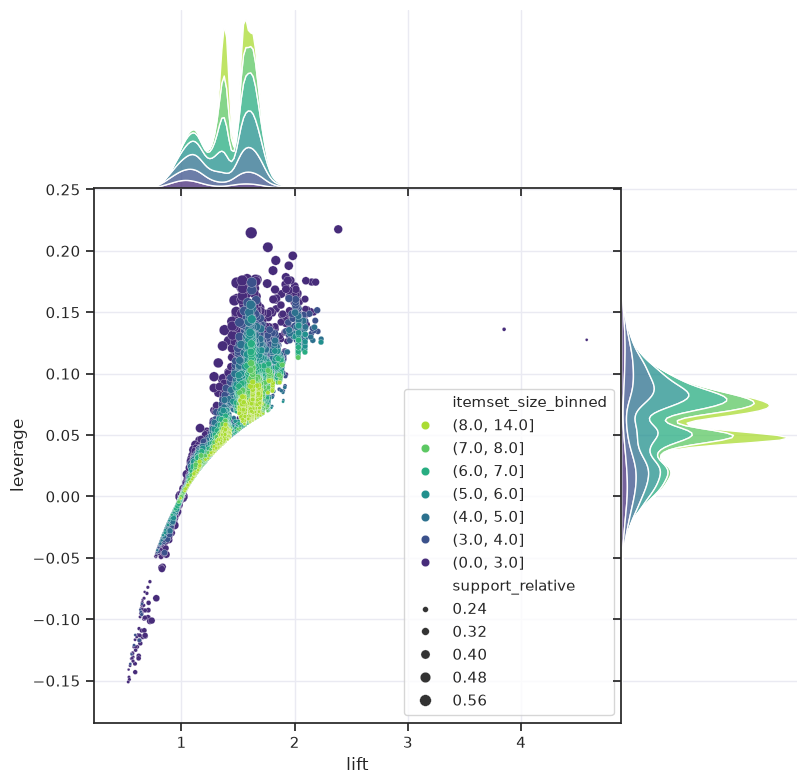

In [68]:
FIa70_dtf.sort_values(by=["itemset_size", "support_count"], inplace=True)
ax = seaborn.jointplot(FIa70_dtf, x="lift", y="leverage", hue="itemset_size_binned",
                      height=8, space=0, ratio=3, marginal_kws={'multiple':'stack'},
                    joint_kws={"size": FIa70_dtf["support_relative"], "sizes": (4, 80)},
                      hue_order=size_order, palette=size_palette)

11. <a id="input_11"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the figure, and to explain what they mean.
In particular, consider the following questions.
What do the marginal plots reveal about the distribution of lift and leverage across itemsets of different sizes?
What common aspects and differences between lift and leverage are visible in the scatter plot?
What do the two outliers on the right side of the scatter plot correspond to?
</span>

✏️
...

### Mining itemsets with less common items

Items that occur in fewer transactions than the minimum support threshold cannot appear in any frequent itemset.
To obtain itemsets that involve items beyond the most common ones, we need to lower the minimum support threshold. To avoid the many frequent combinations of common items and keep the mining feasible, we restrict the size of the itemsets.

We run the mining algorithm once more, with a fairly low minimum support threshold, requiring occurrence in just ten transactions for an itemset to be considered frequent, and limiting the size of the itemsets to three items. Accordingly, we set the `supp` parameter to -10 and the `zmax` parameter to 3.

In [69]:
%%time
FIa10z3 = fim(transactions, target="s", supp=-10, zmax=3)
print(f"Found {len(FIa10z3)} itemsets")

Found 14758 itemsets
CPU times: user 226 ms, sys: 5 μs, total: 226 ms
Wall time: 226 ms


The algorithm returned many thousands of itemsets in less than a second.

As previously, we tabulate the results, with one itemset per row and the same columns.

However, note that, given that we only mined itemsets up to size three, we do not have the support counts of itemsets of size four needed to determine which itemsets of size three are closed. We can only determine whether itemsets with one or two items are closed.

We filter out itemsets that include two items from the geographic group, as the two items must represent geographic units of different levels where the higher-level one is implied by the lower-level one, [as discussed earlier](#discuss_geo-redundant).

In [70]:
%%time
L = [[fi[0], tuple(sorted(fi[0])), tuple([items_dtf.at[x, "label"] for x in sorted(fi[0])]), len(fi[0]), fi[1], fi[1]/nb_tot]
     for fi in FIa10z3 if sum([items_dtf.at[i, "group"].startswith("geo") for i in fi[0]]) <= 1]
FIa10z3_dtf = pandas.DataFrame(L, columns=["itemset_org", "itemset_ids", "itemset_labels", "itemset_size", "support_count", "support_relative"])

FIa10z3_supports = dict(FIa10z3_dtf[["itemset_ids", "support_count"]].values)
last_i = items_dtf.shape[0]-1
FIa10z3_dtf["open_items"] = FIa10z3_dtf.apply(lambda elem:
            tuple([si for (superset, si) in get_direct_supersets_ids(elem["itemset_ids"], last_i)
                   if FIa10z3_supports.get(superset, 0) == elem["support_count"]]) if elem["itemset_size"] < 3 else None,
                                        axis=1)
FIa10z3_dtf["closed"] = FIa10z3_dtf.apply(lambda elem: len(elem["open_items"]) == 0 if elem["open_items"] is not None else None, axis=1)

tmp = FIa10z3_dtf.apply(lambda elem: (elem["support_count"]*nb_tot, ()) if elem["itemset_size"] == 1 else
            sorted([(FIa10z3_supports.get(lhs)*FIa10z3_supports.get(rhs), lhs)
                       for (lhs, rhs) in get_bipartitions(elem["itemset_ids"])])[-1],
                                        axis=1)
FIa10z3_dtf["max_expected_support_relative"] = tmp.apply(lambda elem: elem[0]/nb_tot**2)
FIa10z3_dtf["max_expected_partition"] = tmp.apply(lambda elem: elem[1])

FIa10z3_dtf["leverage"] = FIa10z3_dtf["support_relative"]-FIa10z3_dtf["max_expected_support_relative"]
FIa10z3_dtf["lift"] = FIa10z3_dtf["support_relative"]/FIa10z3_dtf["max_expected_support_relative"]
print(f"Processed {FIa10z3_dtf.shape[0]} itemsets")

Processed 13985 itemsets
CPU times: user 1.14 s, sys: 1.03 ms, total: 1.14 s
Wall time: 1.14 s


We plot the distribution of frequent itemsets by support count, grouped by itemset size.

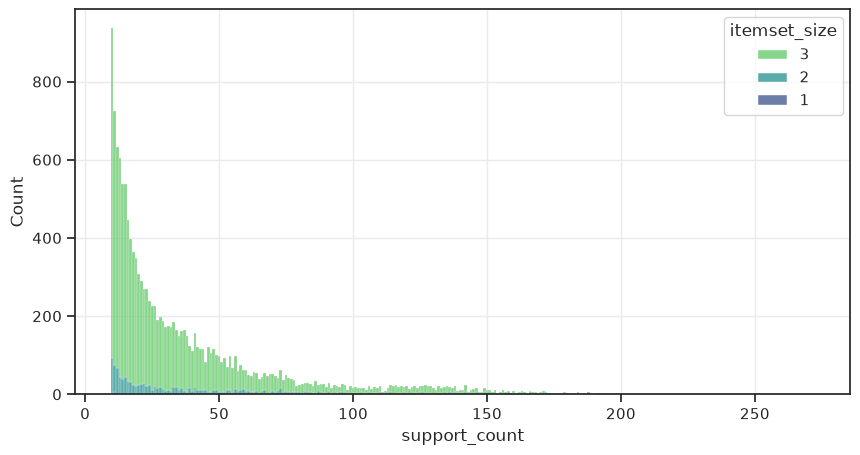

In [71]:
size_palette = "viridis_r"
size_order = map(str, range(3, 0, -1))
ax = seaborn.histplot(x=FIa10z3_dtf["support_count"], hue=FIa10z3_dtf["itemset_size"].map(lambda x: str(x)), multiple='stack', discrete=True,
                      hue_order=size_order, palette=size_palette)

12. <a id="input_12"></a><span style="background-color:#FEDA8B;">
Write a sentence to describe the distribution of short itemsets with respect to support count.
</span>

✏️
...

We sort the itemsets by increasing lift values and display the top five and last five.

In [72]:
FIa10z3_dtf.sort_values(by="lift")

,itemset_org,itemset_ids,itemset_labels,itemset_size,support_count,support_relative,open_items,closed,max_expected_support_relative,max_expected_partition,leverage,lift
11396,"(13, 0, 45)","(0, 13, 45)","(party_democrat, physician_y, exports_n)",3,10,0.022989,None,None,0.211653,"(0,)",-0.188664,0.108614
13034,"(28, 16, 0)","(0, 16, 28)","(party_democrat, el-salvador_y, missile_y)",3,10,0.022989,None,None,0.210628,"(16,)",-0.187639,0.109143
11395,"(13, 0, 40)","(0, 13, 40)","(party_democrat, physician_y, superfund_y)",3,10,0.022989,None,None,0.204598,"(0,)",-0.181609,0.112360
11394,"(13, 0, 3)","(0, 3, 13)","(party_democrat, infants_n, physician_y)",3,10,0.022989,None,None,0.200365,"(0,)",-0.177376,0.114733
11400,"(13, 0, 16)","(0, 13, 16)","(party_democrat, physician_y, el-salvador_y)",3,12,0.027586,None,None,0.237051,"(0,)",-0.209465,0.116372
...,...,...,...,...,...,...,...,...,...,...,...,...
2833,"(5, 100)","(5, 100)","(water_?, geo-division_East North Central)",2,23,0.052874,(),True,0.020293,"(5,)",0.032580,2.605469
69,"(41, 47)","(41, 47)","(crime_?, south-africa_?)",2,11,0.025287,(),True,0.009343,"(41,)",0.015944,2.706448
489,"(63, 5)","(5, 63)","(water_?, geo-state_IL)",2,16,0.036782,(),True,0.005581,"(5,)",0.031201,6.590909
228,"(32, 35)","(32, 35)","(synfuels_?, education_?)",2,11,0.025287,(),True,0.003440,"(32,)",0.021847,7.350230


13. <a id="input_13"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the listed itemsets and to explain what they mean.
In particular, are the same items appearing in itemsets that have a low lift and those that have a high lift?
</span>

✏️
...

### Mapping the support of itemsets

Since we know which congressional district each row in our dataset represents, we can add the geographic coordinates of the districts, allowing us visualize the data and in particular the support of itemsets as maps. For more details about handling the geospatial coordinates and mapping the data, [see the separate notebook](https://github.com/nurblageij/data-exploration/blob/main/datasets/explore_congress.ipynb).

We use the `geopandas` library (https://geopandas.org/en/stable), which builds on the `pandas` library, adding functionalities to handle geospatial data.

In [73]:
import geopandas

The United States Congressional District Shapefiles website at https://cdmaps.polisci.ucla.edu/ provides digital boundary definitions for every congressional district of the United States of America in use between 1789 and 2025.

We download the map data for the districts of the 98th Congress and load them.

In [74]:
H098districts_path = "./geo_districts098/districts098.shp"
H098districts_gdf = geopandas.read_file(H098districts_path, columns=["STATENAME", "DISTRICT"])\
    .rename({"STATENAME": "state", "DISTRICT": "district"}, axis=1)
H098districts_gdf

,state,district,geometry
0,Alabama,1.0,"MULTIPOLYGON (((-88.05205 30.19698, -88.05337 ..."
1,Alabama,2.0,"POLYGON ((-86.25816 32.50061, -86.25742 32.500..."
2,Alabama,3.0,"POLYGON ((-85.39404 33.93974, -85.39252 33.932..."
3,Alabama,4.0,"POLYGON ((-85.58322 34.8603, -85.58314 34.8603..."
4,Alabama,5.0,"POLYGON ((-85.59238 34.91049, -85.59232 34.909..."
...,...,...,...
432,Wisconsin,6.0,"MULTIPOLYGON (((-88.45524 44.18785, -88.45725 ..."
433,Wisconsin,7.0,"MULTIPOLYGON (((-90.70998 46.64066, -90.71324 ..."
434,Wisconsin,8.0,"MULTIPOLYGON (((-86.77505 45.36607, -86.77583 ..."
435,Wisconsin,9.0,"POLYGON ((-87.8791 43.09962, -87.87886 43.0989..."


We assign unique names to the records by combining state name and district number.
At-large districts are numbered with value 0, whereas in our dataset all districts are numbered starting from 1.
For a given state, if there is no district numbered 1, we use the district numbered 0 instead.

In [75]:
H098districts_gdf["name"] = ["%s-%03d" % tuple(v) for v in H098districts_gdf[["state", "district"]].values]
H098districts_gdf.set_index("name", inplace=True)
for v in H098districts_gdf.loc[H098districts_gdf["district"]==0, ["state", "district"]].values:
    one_k = "%s-%03d" % (v[0], 1)
    if one_k not in H098districts_gdf.index:
        H098districts_gdf.loc[one_k] =  H098districts_gdf.loc["%s-%03d" % tuple(v)].copy()
        H098districts_gdf.loc[one_k,"name"] = one_k
        H098districts_gdf.loc[one_k,"district"] = 1

We combine the geographic data with our extended dataset. The result is variant of the `congress_ext_dtf` table that contains geospatial information, so we denote it `congress_ext_gdf`.

We also compute a rough estimate of the surface area of each district, as the sum of the areas of the polygons representing its geometry.
To do this, we need to project the geographic coordinates in a reference system that preserves area. That is, we need to use an [equal-area map projection](https://en.wikipedia.org/wiki/Equal-area_projection), such as the world sinusoidal projection, identified as `esri:54008`.

In [76]:
data_crs = "+proj=longlat +ellps=GRS80 +towgs84=0,0,0,0,0,0,0 +no_defs"
district_name = ["%s-%03d" % tuple(v) for v in congress_ext_dtf[["state_long", "district_code"]].values]
congress_ext_gdf = geopandas.GeoDataFrame(congress_ext_dtf,
    geometry=H098districts_gdf.loc[district_name, "geometry"].values,
    crs=data_crs)
congress_ext_gdf["name"] = ["%s-%03d" % tuple(v) for v in congress_ext_dtf[["state_abbrev", "district_code"]].values]
congress_ext_gdf.set_index("name", drop=False, inplace=True)
congress_ext_gdf["surface_area"] = congress_ext_gdf.to_crs("esri:54008").geometry.area*10**-6

We modify the Boolean data table `boolean_dtf` to use the same index as `congress_ext_gdf`.

In [77]:
boolean_dtf["ord"] =  boolean_dtf.index.values
boolean_dtf["name"] = congress_ext_gdf["name"].values
boolean_dtf.set_index("name", drop=False, inplace=True)
boolean_dtf

,party_democrat,party_republican,infants_?,infants_n,infants_y,water_?,water_n,water_y,budget_?,budget_n,...,geo-division_West South Central,geo-region_Midwest,geo-region_Northeast,geo-region_South,geo-region_West,"age_(29.999, 45.0]","age_(45.0, 55.0]","age_(55.0, 84.0]",ord,name
name,,,,,,,,,,,,,,,,,,,,,
AL-001,False,True,False,True,False,False,False,True,False,True,...,False,False,False,True,False,False,False,True,0,AL-001
AL-002,False,True,False,True,False,False,False,True,False,True,...,False,False,False,True,False,False,False,True,1,AL-002
AL-003,True,False,True,False,False,False,False,True,False,False,...,False,False,False,True,False,False,False,True,2,AL-003
AL-004,True,False,False,True,False,False,False,True,False,False,...,False,False,False,True,False,False,False,True,3,AL-004
AL-005,True,False,False,False,True,False,False,True,False,False,...,False,False,False,True,False,False,True,False,4,AL-005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WI-006,False,True,False,True,False,False,True,False,False,False,...,False,True,False,False,False,True,False,False,430,WI-006
WI-007,True,False,False,True,False,False,True,False,False,False,...,False,True,False,False,False,False,True,False,431,WI-007
WI-008,False,True,False,True,False,True,False,False,False,True,...,False,True,False,False,False,False,True,False,432,WI-008


We write a function for plotting geospatial data...

In [78]:
def make_plot(gdf, title, plot_parameters, crs, codes_votes=None, dtl_desc=None, save_path=None, ax=None, figsize=(16,10)):
    """Plots geospatial data.

        Parameters
        ----------
        gdf: GeoDataFrame
            The GeoDataFrame containing the feature values and the geometry of the objects to plot
        title: str
            The title of the plot
        plot_parameters: dict
            Parameters for plotting, especially "column" must be specified
            Optional parameters include
                "vmin", "vmax" and "palette", by default from 0 to 1 with "coolwarm" colormap
                "no_annot" ids of elements for which to skip annotation in the main map
                "insets" list of parameters for inset maps, including "ids" listing the elements to plot in the inset
        crs: pyproj.CRS
            The Coordinate Reference System (CRS) code of the projection to use for the map
        codes_votes: list of tuples
            The sorted list of (party, vote type) pairs with their associated numerical value, as used to obtain the column to plot,
            used to draw a histogram bar that also serves as legend, if None no histogram bar is drawn
        dtl_desc: str
            The detailed description of the roll call, added as text to the figure if not None
        save_path: str
            A filepath where to save the generated figure, works only if ax is None
        ax: pyplot.Axes
            The axes in which to plot the data, if None a new figure and subplot are created
        figsize: 2-tuple of floats
            Figure dimension (width, height) in inches
    """

    fig = None
    if ax is None:
        fig = plt.figure(1, figsize=figsize)
        ax = fig.add_subplot()

    legend_kwds = {}
    if codes_votes == True:
        legend_kwds = {"cax": ax.inset_axes(plot_parameters.get("bar_bounds", [0.55, 0.85, 0.45, 0.08])),
                        "orientation": "horizontal"}

    # Plotting main map
    drop_ids = set(plot_parameters.get("drop_ids", [])).union(*[ip["ids"] for ip in plot_parameters.get("insets", [])])
    main_pgdf = gdf.drop(drop_ids).to_crs(crs)

    main_plot_parameters = {"no_annot": drop_ids}
    main_plot_parameters.update(plot_parameters)
    main_pgdf.apply(lambda elem: annotate_element(ax, elem, main_plot_parameters), axis=1);
    main_pgdf.boundary.plot(ax=ax, color="black", linewidth=.4, alpha=0.5);
    main_pgdf.plot(ax=ax, column=plot_parameters["column"],
                  vmin=plot_parameters.get("vmin", 0), vmax=plot_parameters.get("vmax", 1),
                  cmap=plot_parameters.get("cmap", "coolwarm"), legend=len(legend_kwds)>0, legend_kwds=legend_kwds,
                  edgecolor="black", linewidth=0.4)


    # Plotting inset maps
    for inset_parameters in plot_parameters.get("insets", []):
        inset_pgdf = gdf.loc[inset_parameters["ids"]].to_crs(inset_parameters.get("crs", crs))

        inset_ax = ax.inset_axes(inset_parameters.get("bounds", [0.01, 0.01, 0.1, 0.1]))

        inset_pgdf.apply(lambda elem: annotate_element(inset_ax, elem, plot_parameters), axis=1);
        inset_pgdf.boundary.plot(ax=inset_ax, color="black", linewidth=.4, alpha=0.5);
        inset_pgdf.plot(ax=inset_ax, column=plot_parameters["column"],
                    vmin=plot_parameters.get("vmin", 0), vmax=plot_parameters.get("vmax", 1),
                    cmap=plot_parameters.get("cmap", "coolwarm"), legend=False,
                  edgecolor="black", linewidth=0.4)
        if "bbox_buffer" in inset_parameters:
            inset_ax.set_xlim([inset_parameters["bbox_buffer"][0],inset_parameters["bbox_buffer"][2]])
            inset_ax.set_ylim([inset_parameters["bbox_buffer"][1],inset_parameters["bbox_buffer"][3]])
        inset_ax.set_xticks([])
        inset_ax.set_yticks([])

    if codes_votes is not None and len(legend_kwds) == 0:
        bar_ax = ax.inset_axes(plot_parameters.get("bar_bounds", [0.55, 0.85, 0.45, 0.08]))
        make_bar_stack(bar_ax, gdf[plot_parameters["column"]], codes_votes, plot_parameters, set_lims=True)

    ylim = ax.get_ylim()
    if plot_parameters.get("bar_pad", 0) > 0:
        ax.set_ylim([ylim[0], ylim[1]+plot_parameters["bar_pad"]*(ylim[1]-ylim[0])])
    elif plot_parameters.get("bar_pad", 0) < 0:
        ax.set_ylim([ylim[0]+plot_parameters["bar_pad"]*(ylim[1]-ylim[0]), ylim[1]])
    if title is not None:
        ax.set_title(title)
    if dtl_desc is not None and fig is not None:
        fig.text(0.5, 0., dtl_desc, ha="center", wrap=True);

    ax.axis("off");

    if save_path is not None and fig is not None:
        fig.savefig(save_path)

    return ax

...and a function for annotating the elements of our plots.
A marker is drawn for districts with a surface area less than `max_area_marker`. A text label containing by default the name of the district is shown for districts with a surface area at least `min_area_label`.

In [79]:
def annotate_element(ax, elem, plot_parameters={}):
    """Prepare the annotation for an element.

        Parameters
        ----------
        ax: pyplot.Axes
            The axes in which to plot the data
        elem:
            The object to annotate
        plot_parameters : dict
            Parameters for plotting.
            Optional parameters include
                "vmin", "vmax" and "palette", by default from 0 to 1 with "coolwarm" colormap
                "no_annot" ids of elements for which to skip annotation
                "max_area_marker" maximum surface area of elements to annotate with a marker
                "min_area_label" minimum surface area of elements to annotate with a text label
                "label_str" a formatting string to prepare text labels, by default the element name is used
                "fontsize", "alpha", "mrk_alpha", "mrk_shape", "mrk_size", "mrk_edge"
"""

    if plot_parameters.get("no_annot") is None or elem.name not in plot_parameters.get("no_annot"):

        vfrac = (plot_parameters.get("vmax", 1) - elem[plot_parameters["column"]])/(
                    plot_parameters.get("vmax", 1) - plot_parameters.get("vmin", 0))
        palette = plot_parameters.get("palette", seaborn.color_palette("coolwarm", as_cmap=True))
        txt_color = get_contrasting_color(vfrac, palette)
        box_color = palette(1-vfrac)

        if elem["surface_area"] < plot_parameters.get("max_area_marker", -1):
            ax.plot(elem.geometry.centroid.coords[0][0], elem.geometry.centroid.coords[0][1],
                    color=box_color, markeredgecolor=txt_color,
                    marker=plot_parameters.get("mrk_shape", "o"), markersize=plot_parameters.get("mrk_size", 6),
                    markeredgewidth=plot_parameters.get("mrk_edge", 1), alpha=plot_parameters.get("mrk_alpha", 0.95), zorder=10)
        if elem["surface_area"] >= plot_parameters.get("min_area_label", -1):
            if "label_str" in plot_parameters:
                text = plot_parameters["label_str"].format(elem=elem)
            else:
                text = elem.name
            ax.annotate(text=text,
                xy=elem.geometry.centroid.coords[0],
                ha="center", fontsize=plot_parameters.get("fontsize", "x-small"), color=txt_color,
                bbox=dict(boxstyle="round", pad=.1, lw=0, fc=box_color, alpha=plot_parameters.get("alpha", 0.8)))

We choose a projection for the map and set parameters for the inset maps to represent Alaska and Hawaii.

In [80]:
# crs_main = 10598 # WGS_1984_GLANCE_North_America
# crs_main = 27705 # WGS_1984_Equi7_North_America
# crs_main = 3347 # NAD_1983_Statistics_Canada_Lambert
crs_main = "+proj=longlat +ellps=GRS80 +towgs84=0,0,0,0,0,0,0 +no_defs"

insets = [{"ids": ["AK-001"],
    "bounds": [0.01, 0.01, 0.25, 0.25],
    "bbox_buffer": [-180, 50, -127, 73],
    "crs": crs_main}, # "EPSG:4326"
    {"ids": ["HI-001", "HI-002"],
    "bounds": [0.18, 0.01, 0.2, 0.1],
    "bbox_buffer": [-161, 18, -154, 23],
    "crs": crs_main}
    ]

We are ready to plot the support of an itemset on a map. As an example, we randomly select an itemset among those with four items occurring in at most a quarter of the transactions, with a lift higher than two, which do not involve party affiliation nor have the same support as an itemset that does.

In [81]:
S = FIa70_dtf[(FIa70_dtf["itemset_size"]==4) & (FIa70_dtf["support_relative"]<0.25)
    & (FIa70_dtf["lift"]>2)
    & (FIa70_dtf["itemset_ids"].map(lambda x: (0 not in x) & (1 not in x)))
    & (FIa70_dtf["open_items"].map(lambda x: (0 not in x) & (1 not in x)))
    ].sample(1, random_state=RNG)
S

,itemset_org,itemset_ids,itemset_labels,itemset_size,support_count,support_relative,itemset_size_binned,open_items,closed,max_expected_support_relative,max_expected_partition,leverage,lift
16920,"(9, 21, 37, 24)","(9, 21, 24, 37)","(budget_n, satellite_n, nicaragua_n, education_y)",4,107,0.245977,"(3.0, 4.0]",(),True,0.111571,"(21,)",0.134406,2.20467


We make the map showing the support of this itemset.

We use the Boolean data table to compute the support set of the itemset as a list of Boolean values indicating whether or not the itemset occurs in the corresponding row.
Then, these Boolean values are mapped to values in the unit interval that will determine the color used to depict the corresponding district.
Districts corresponding to transactions where the itemset occurs will be depicted with bright colors whereas districts corresponding to transactions where the itemset does not occur will be depicted with muted colors, with blue and red used to depict districts whose representative is affiliated respectively with the Democratic Party and with the Republican Party, as usual.
Hence, true maps to values close to 0 and 1 depending on the affiliation of the representative, while false maps to values close to 0.5, either below or above, accordingly.

CPU times: user 6.14 s, sys: 53 ms, total: 6.19 s
Wall time: 6.19 s


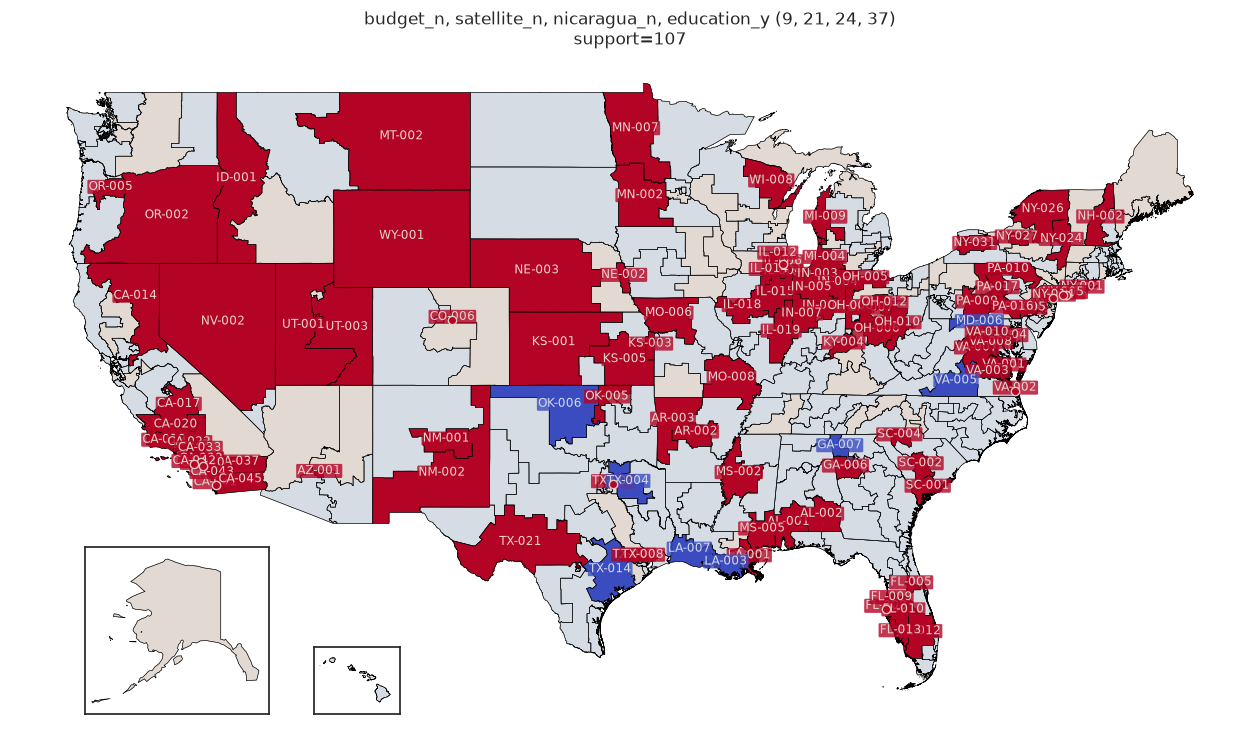

In [82]:
%%time
itemset_index = S.index[0]
item_ids = list(FIa70_dtf.at[itemset_index, "itemset_ids"])
# item_ids = [19, 25]
column = "tmp_support_num"
supp = boolean_dtf.iloc[:, item_ids].all(axis=1)
congress_ext_gdf[column] = congress_ext_gdf.apply(
    lambda elem: (1-supp[elem.name])/2.1 if elem["party"]=="democrat" else 1-(1-supp[elem.name])/2.1,
    axis=1)

pp_sd = {"column": column,
    "max_area_marker": 10**3,
    "min_area_label": 0,
    "insets": insets,
    "no_annot": congress_ext_gdf.loc[~supp, "name"].tolist()
    }

title_str =  "%s (%s)\nsupport=%d" %(", ".join(items_dtf.loc[item_ids]["label"].values),
                                    ", ".join(map(str, item_ids)),
                                    supp.sum())
make_plot(congress_ext_gdf, title_str, pp_sd, crs_main, None);

14. <a id="input_14"></a><span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the itemset and its support as displayed on the map.
Make sure your statement agrees with the output after changing the random seed.
</span>

✏️
...

## Conclusion

15. <a id="input_15"></a><span style="background-color:#FEDA8B;">
Write a few sentences of conclusion, summarizing what you have learned from the notebook about the dataset, the frequent itemset miner, the analysis pipeline, the different types of itemsets and their characteristics.
</span>

✏️
...

## References

- <a id="cite_note-gengh06"></a>[^](#cite_ref-gengh06) Geng, L., & Hamilton, H. J. (2006). Interestingness measures for data mining: A survey. ACM Computing Surveys (CSUR), 38(3), 9. https://doi.org/10.1145/1132960.1132963
- <a id="cite_note-webb10"></a>[^](#cite_ref-webb10) Webb, G. I. (2010). Self-sufficient itemsets: An approach to screening potentially interesting associations between items. ACM Transactions on Knowledge Discovery from Data (TKDD), 4(1), 3:1-3:20. https://doi.org/10.1145/1644873.1644876